# CLEAR ATS — Uncertainty (Monte Carlo) notebook

This notebook runs the uncertainty calculation **directly in the notebook** (no `subprocess`, no Flask app).

Workflow:
1. load one scenario JSON (example: `california.json`)
2. load your model code from `footprint_model.py`
3. run Monte Carlo sampling (`mc_runs`)
4. compute P05 / P50 / P95 quantiles
5. plot the uncertainty band

If JSON has **no** `data_uncertainty` and no inline distribution specs, the band will collapse. This notebook can optionally inject a small example `data_uncertainty`.

In [2]:
# Cell 1 — setup
from pathlib import Path
import json
import copy
import io
import contextlib
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---- USER SETTINGS ----
# Change to your local config file
# CONFIG_PATH = r"C:\research\sustaibabilityplot\CLEAR_ATS\CLEAR_ATS\configs\california.json"
CONFIG_PATH = r"D:\JHU\research\sustainabletransportation\configs\ohio.json"

# Years to simulate (68 means 2024..2092)
YEARS = 68

# Monte Carlo runs (set > 1 to get quantiles/bands)
MC_RUNS = 200

# RNG seed (reproducible)
SEED = 42

# Policy to apply: "baseline", "aggressive", "conservative", or "all"
POLICY_NAME = "all"

# If your JSON has no uncertainty specs, set True to inject a small example block.
ADD_EXAMPLE_UNCERTAINTY = True

# Output folder (default: <project_root>/results_notebook)
OUTPUT_DIR_NAME = "results_notebook"

In [3]:
# Cell 2 — locate project root and load your model module from footprint_model.py
config_path = Path(CONFIG_PATH)
if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

project_root = config_path.parent.parent  # .../CLEAR_ATS/CLEAR_ATS
model_path = project_root / "footprint_model.py"

if not model_path.exists():
    raise FileNotFoundError(
        "Cannot find footprint_model.py next to your configs folder.\n"
        f"Expected: {model_path}\n"
        "Fix: set model_path to the correct file."
    )

spec = importlib.util.spec_from_file_location("footprint_model", str(model_path))
fm = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(fm)

print("Loaded model from:", model_path)
print("Loaded config from:", config_path)
print("Project root:", project_root)

out_dir = project_root / OUTPUT_DIR_NAME
out_dir.mkdir(parents=True, exist_ok=True)
print("Output dir:", out_dir)

Loaded model from: D:\JHU\research\sustainabletransportation\footprint_model.py
Loaded config from: D:\JHU\research\sustainabletransportation\configs\ohio.json
Project root: D:\JHU\research\sustainabletransportation
Output dir: D:\JHU\research\sustainabletransportation\results_notebook


In [4]:
# Cell 3 — load scenario config and apply policy override
with open(config_path, "r") as f:
    scenario_config = json.load(f)

policy_scenarios = scenario_config.get("policy_scenarios", {})
if POLICY_NAME == "all":
    policy_items = list(policy_scenarios.items()) if policy_scenarios else [("baseline", {})]
else:
    policy_patch = policy_scenarios.get(POLICY_NAME, {})
    policy_items = [(POLICY_NAME, policy_patch)]

print("Available policies:", list(policy_scenarios.keys()) if policy_scenarios else ["baseline"])
print("Selected:", [p for p, _ in policy_items])

Available policies: ['baseline', 'aggressive', 'conservative']
Selected: ['baseline', 'aggressive', 'conservative']


In [5]:
# # Cell 4 — (optional) inject example uncertainty if your JSON does not define any

# def inject_example_data_uncertainty(cfg):
#     '''
#     Adds a small data_uncertainty block to cfg in-place (returns cfg).
#     This is ONLY for getting a visible band quickly.
#     Adjust the distributions to match your own assumptions.
#     '''
#     cfg.setdefault("data_uncertainty", {})
#     du = cfg["data_uncertainty"]

#     # --- Initial state uncertainty ---
#     du.setdefault("initial_data", {})
#     du["initial_data"].setdefault(
#         "total_cars",
#         {"dist": "normal", "mean": cfg["initial_data"]["total_cars"], "sd": 500000, "min": 1, "integer": True},
#     )
#     du["initial_data"].setdefault(
#         "total_intersections",
#         {"dist": "normal", "mean": cfg["initial_data"]["total_intersections"], "sd": 20000, "min": 1, "integer": True},
#     )
#     du["initial_data"].setdefault(
#         "f_clean", {"dist": "beta", "mean": cfg["initial_data"]["f_clean"], "kappa": 60, "min": 0, "max": 1}
#     )

#     # EV share drives total_ev (your code uses ev_share -> total_ev = total_cars * ev_share)
#     base_ev_share = float(cfg["initial_data"]["total_ev"]) / float(cfg["initial_data"]["total_cars"])
#     du["initial_data"].setdefault(
#         "ev_share", {"dist": "normal", "mean": base_ev_share, "sd": 0.01, "min": 0, "max": 1}
#     )

#     # --- Growth rate uncertainty (small) ---
#     du.setdefault("growth_rates", {})
#     for k, rel_sd in [
#         ("ev", 0.15),
#         ("clean_energy", 0.20),
#         ("total_car_increase", 0.50),
#         ("efficiency_doubling", 0.10),
#     ]:
#         if k in cfg.get("growth_rates", {}):
#             mean = float(cfg["growth_rates"][k])
#             du["growth_rates"].setdefault(
#                 k, {"dist": "normal", "mean": mean, "sd": abs(mean) * rel_sd, "min": 0}
#             )

#     # --- Emission factor uncertainty ---
#     du.setdefault("emission_factors", {})
#     for k, rel_sd in [("e_clean", 0.30), ("e_fossil", 0.15), ("e_gasoline", 0.10)]:
#         if k in cfg.get("emission_factors", {}):
#             mean = float(cfg["emission_factors"][k])
#             du["emission_factors"].setdefault(
#                 k, {"dist": "lognormal", "mean": mean, "cv": rel_sd, "min": 0}
#             )

#     # --- Power table uncertainty (example: lognormal CV=10%) ---
#     du.setdefault("consumption_rates", {})

#     if "ecav_power" in cfg.get("consumption_rates", {}):
#         du["consumption_rates"].setdefault("ecav_power", {})
#         for lvl, triple in cfg["consumption_rates"]["ecav_power"].items():
#             du["consumption_rates"]["ecav_power"].setdefault(lvl, {})
#             for kk, vv in triple.items():
#                 du["consumption_rates"]["ecav_power"][lvl].setdefault(
#                     kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
#                 )

#     if "sti_power" in cfg.get("consumption_rates", {}):
#         du["consumption_rates"].setdefault("sti_power", {})
#         for lvl, triple in cfg["consumption_rates"]["sti_power"].items():
#             du["consumption_rates"]["sti_power"].setdefault(lvl, {})
#             for kk, vv in triple.items():
#                 du["consumption_rates"]["sti_power"][lvl].setdefault(
#                     kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
#                 )

#     return cfg

# def config_has_any_uncertainty(cfg):
#     return bool(cfg.get("data_uncertainty")) or fm.has_distribution_spec(cfg)

# if ADD_EXAMPLE_UNCERTAINTY and (not config_has_any_uncertainty(scenario_config)):
#     scenario_config = inject_example_data_uncertainty(scenario_config)
#     print("Injected example data_uncertainty into the loaded config.")
# else:
#     print("Using uncertainty settings already present in your config (or ADD_EXAMPLE_UNCERTAINTY=False).")

# print("has_distribution_spec =", fm.has_distribution_spec(scenario_config))
# print("has data_uncertainty =", bool(scenario_config.get("data_uncertainty")))
# Cell 4 — inject uncertainty blocks if your JSON does not define any

def inject_uncertainty_blocks(cfg):
    """
    Injects three uncertainty layers if missing.

    Layer A  today parameter uncertainty -> cfg["data_uncertainty"]
    Layer B  load uncertainty             -> cfg["model_variants"]["load_model"]
    Layer C  future tech uncertainty      -> cfg["model_variants"]["tech_model"]

    This is meant as a notebook-side starting point.
    Replace distribution widths with evidence-based values when available.
    """
    cfg = copy.deepcopy(cfg)

    # -----------------------------
    # Layer A: today parameter uncertainty
    # -----------------------------
    cfg.setdefault("data_uncertainty", {})
    du = cfg["data_uncertainty"]

    du.setdefault("initial_data", {})
    du["initial_data"].setdefault(
        "total_cars",
        {"dist": "normal", "mean": cfg["initial_data"]["total_cars"], "sd": 0.10 * cfg["initial_data"]["total_cars"],
         "min": 1, "integer": True},
    )
    du["initial_data"].setdefault(
        "total_intersections",
        {"dist": "normal", "mean": cfg["initial_data"]["total_intersections"], "sd": 0.10 * cfg["initial_data"]["total_intersections"],
         "min": 1, "integer": True},
    )
    du["initial_data"].setdefault(
        "f_clean",
        {"dist": "beta", "mean": cfg["initial_data"]["f_clean"], "kappa": 60, "min": 0, "max": 1},
    )

    # Use beta for a share rather than normal
    base_ev_share = float(cfg["initial_data"]["total_ev"]) / float(cfg["initial_data"]["total_cars"])
    du["initial_data"].setdefault(
        "ev_share",
        {"dist": "beta", "mean": base_ev_share, "kappa": 200, "min": 0, "max": 1},
    )

    du.setdefault("growth_rates", {})
    # Positive rates: lognormal is usually safer than normal
    for k, sigma in [
        ("ev", 0.25),
        ("clean_energy", 0.30),
        ("total_car_increase", 0.40),
        ("efficiency_doubling", 0.20),
    ]:
        if k in cfg.get("growth_rates", {}):
            med = float(cfg["growth_rates"][k])
            du["growth_rates"].setdefault(
                k, {"dist": "lognormal", "median": med, "sigma": sigma, "min": 0.0}
            )

    du.setdefault("emission_factors", {})
    for k, cv in [("e_clean", 0.30), ("e_fossil", 0.15), ("e_gasoline", 0.10)]:
        if k in cfg.get("emission_factors", {}):
            mean = float(cfg["emission_factors"][k])
            du["emission_factors"].setdefault(
                k, {"dist": "lognormal", "mean": mean, "cv": cv, "min": 0}
            )

    # Baseline table uncertainty for today measurement error and modeling error
    du.setdefault("consumption_rates", {})

    if "ecav_power" in cfg.get("consumption_rates", {}):
        du["consumption_rates"].setdefault("ecav_power", {})
        for lvl, triple in cfg["consumption_rates"]["ecav_power"].items():
            du["consumption_rates"]["ecav_power"].setdefault(lvl, {})
            for kk, vv in triple.items():
                du["consumption_rates"]["ecav_power"][lvl].setdefault(
                    kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
                )

    if "sti_power" in cfg.get("consumption_rates", {}):
        du["consumption_rates"].setdefault("sti_power", {})
        for lvl, triple in cfg["consumption_rates"]["sti_power"].items():
            du["consumption_rates"]["sti_power"].setdefault(lvl, {})
            for kk, vv in triple.items():
                du["consumption_rates"]["sti_power"][lvl].setdefault(
                    kk, {"dist": "lognormal", "mean": float(vv), "cv": 0.10, "min": 0}
                )

    # -----------------------------
    # Layer B: load uncertainty
    # -----------------------------
    cfg.setdefault("model_variants", {})
    mv = cfg["model_variants"]

    mv.setdefault("load_model", {})

    # Average utilization multipliers.
    # Median 1.0 means your current table is the reference load.
    mv["load_model"].setdefault(
        "cav_load",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.30, "min": 0.3, "max": 3.0},
    )
    mv["load_model"].setdefault(
        "sti_load",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.35, "min": 0.3, "max": 3.5},
    )

    # Exponents control which subsystem responds to load more strongly.
    # Example: communication tends to scale more with activity than sensing.
    mv["load_model"].setdefault(
        "exponent",
        {"sensing": 0.2, "computing": 1.0, "communication": 1.1},
    )

    # -----------------------------
    # Layer C: future tech uncertainty
    # -----------------------------
    mv.setdefault("tech_model", {})

    # These factors represent future non-compute improvements that your current
    # "efficiency_doubling" does not directly capture.
    mv["tech_model"].setdefault(
        "cav_sensor_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.25, "min": 0.4, "max": 1.8},
    )
    mv["tech_model"].setdefault(
        "cav_comm_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.30, "min": 0.4, "max": 2.2},
    )
    mv["tech_model"].setdefault(
        "sti_sensor_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.25, "min": 0.4, "max": 1.8},
    )
    mv["tech_model"].setdefault(
        "sti_comm_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.30, "min": 0.4, "max": 2.2},
    )

    # Optional: STI compute factor, to represent infrastructure compute hardware divergence
    # beyond what your global efficiency curve captures.
    mv["tech_model"].setdefault(
        "sti_compute_factor",
        {"dist": "lognormal", "median": 1.0, "sigma": 0.20, "min": 0.5, "max": 1.7},
    )

    return cfg


def config_has_any_uncertainty(cfg):
    return bool(cfg.get("data_uncertainty")) or fm.has_distribution_spec(cfg)

if ADD_EXAMPLE_UNCERTAINTY and (not config_has_any_uncertainty(scenario_config)):
    scenario_config = inject_uncertainty_blocks(scenario_config)
    print("Injected uncertainty blocks into the loaded config.")
else:
    print("Using uncertainty settings already present in your config (or ADD_EXAMPLE_UNCERTAINTY=False).")

print("has_distribution_spec =", fm.has_distribution_spec(scenario_config))
print("has data_uncertainty =", bool(scenario_config.get("data_uncertainty")))


Injected uncertainty blocks into the loaded config.
has_distribution_spec = True
has data_uncertainty = True


In [6]:
# Cell 5 — run Monte Carlo and compute quantiles (P05/P50/P95)
def apply_load_and_tech_to_power_tables(sampled_cfg):
    """
    Converts sampled load_model and tech_model into multipliers on the
    per-level power tables inside sampled_cfg["consumption_rates"].

    This changes the estimated CAV and STI energy demand under different load and tech cases.
    """
    mv = sampled_cfg.get("model_variants", {}) or {}
    load_model = mv.get("load_model", {}) or {}
    tech_model = mv.get("tech_model", {}) or {}

    cav_load = float(load_model.get("cav_load", 1.0))
    sti_load = float(load_model.get("sti_load", 1.0))
    expo = load_model.get("exponent", {}) or {}

    exp_s = float(expo.get("sensing", 0.0))
    exp_c = float(expo.get("computing", 0.0))
    exp_m = float(expo.get("communication", 0.0))

    cav_sensor_factor = float(tech_model.get("cav_sensor_factor", 1.0))
    cav_comm_factor = float(tech_model.get("cav_comm_factor", 1.0))
    sti_sensor_factor = float(tech_model.get("sti_sensor_factor", 1.0))
    sti_comm_factor = float(tech_model.get("sti_comm_factor", 1.0))
    sti_compute_factor = float(tech_model.get("sti_compute_factor", 1.0))

    cr = sampled_cfg.get("consumption_rates", {}) or {}

    if "ecav_power" in cr:
        for lvl, triple in cr["ecav_power"].items():
            triple["sensing"] = float(triple["sensing"]) * (cav_load ** exp_s) * cav_sensor_factor
            triple["computing"] = float(triple["computing"]) * (cav_load ** exp_c)
            triple["communication"] = float(triple["communication"]) * (cav_load ** exp_m) * cav_comm_factor

    if "sti_power" in cr:
        for lvl, triple in cr["sti_power"].items():
            triple["sensing"] = float(triple["sensing"]) * (sti_load ** exp_s) * sti_sensor_factor
            triple["computing"] = float(triple["computing"]) * (sti_load ** exp_c) * sti_compute_factor
            triple["communication"] = float(triple["communication"]) * (sti_load ** exp_m) * sti_comm_factor

    return sampled_cfg

def run_one(cfg, years, seed, model_variant=None):
    rng = np.random.default_rng(seed)
    use_sampling = bool(cfg.get("data_uncertainty")) or fm.has_distribution_spec(cfg)
    sampled = fm.sample_config(cfg, rng) if use_sampling else copy.deepcopy(cfg)

    # Ensure sampled keeps the scenario model_variants, not only "fixed_table"
    base_variant = fm._parse_model_variant("fixed_table")
    scenario_mv = sampled.get("model_variants", {}) or {}
    variant = fm._deep_merge(scenario_mv, base_variant)

    # Apply load and future tech multipliers to the sampled power tables
    sampled = apply_load_and_tech_to_power_tables(sampled)

    energy_model = fm.build_energy_model(variant, sampled["consumption_rates"])
    efficiency_model = variant.get("efficiency_model", "smooth")
    retrofit_share = variant.get("retrofit_share", 0.0)

    model = fm.TransportModel(
        sampled["initial_data"],
        sampled["growth_rates"],
        sampled["consumption_rates"],
        sampled["emission_factors"],
        model_variants=variant,
        energy_model=energy_model,
        efficiency_model=efficiency_model,
        retrofit_share=retrofit_share,
    )

    with contextlib.redirect_stdout(io.StringIO()):
        model.run_simulation(years=years)

    return model.results


def run_mc(cfg, years, mc_runs, seed0):
    runs = []
    for i in range(int(mc_runs)):
        runs.append(run_one(cfg, years, int(seed0) + i))
    return runs

quantiles = [0.05, 0.5, 0.95]

all_outputs = {}
for policy_name, policy_patch in policy_items:
    cfg_policy = fm._deep_merge(scenario_config, policy_patch)
    runs = run_mc(cfg_policy, YEARS, MC_RUNS, SEED)
    qdf = fm.compute_quantile_summary(runs, quantiles)

    # Save quantiles
    q_path = out_dir / f"california__policy-{policy_name}__quantiles.csv"
    qdf.to_csv(q_path, index=False)

    all_outputs[policy_name] = {"runs": runs, "qdf": qdf, "q_path": q_path}
    print(f"[{policy_name}] saved quantiles -> {q_path}")

# Show first rows for the selected policy
sel = POLICY_NAME if POLICY_NAME != "all" else list(all_outputs.keys())[0]
display(all_outputs[sel]["qdf"].head(10))

[baseline] saved quantiles -> D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__quantiles.csv
[aggressive] saved quantiles -> D:\JHU\research\sustainabletransportation\results_notebook\california__policy-aggressive__quantiles.csv
[conservative] saved quantiles -> D:\JHU\research\sustainabletransportation\results_notebook\california__policy-conservative__quantiles.csv


,Year,ATS Total Power (kWh)_p05,ATS Total Power (kWh)_p50,ATS Total Power (kWh)_p95,CAV Total Power (kWh)_p05,CAV Total Power (kWh)_p50,CAV Total Power (kWh)_p95,ECAV Power (kWh)_p05,ECAV Power (kWh)_p50,ECAV Power (kWh)_p95,...,Incremented Car Number_p95,EV Fraction_p05,EV Fraction_p50,EV Fraction_p95,Clean Energy Fraction_p05,Clean Energy Fraction_p50,Clean Energy Fraction_p95,Cumulative New Cars_p05,Cumulative New Cars_p50,Cumulative New Cars_p95
0,2024,4.022400e+05,7.590576e+05,1.303915e+06,4.022400e+05,7.590576e+05,1.303915e+06,0.000000,1.929953e+03,7.024172e+03,...,0.000000,0.000472,0.004662,0.013120,0.290112,0.395805,0.504642,4.000000e+02,4.000000e+02,4.000000e+02
1,2025,8.079124e+07,1.212297e+08,1.852577e+08,3.045763e+07,5.193634e+07,8.599030e+07,18232.980920,1.544932e+05,4.868415e+05,...,807028.552349,0.000489,0.004958,0.013866,0.302828,0.416392,0.533268,5.830399e+05,6.874897e+05,8.074261e+05
2,2026,1.711997e+08,2.593324e+08,3.877102e+08,7.848134e+07,1.324498e+08,2.192704e+08,52837.457035,4.279889e+05,1.344377e+06,...,807069.583002,0.000506,0.005261,0.014655,0.319462,0.437318,0.563251,1.165701e+06,1.374637e+06,1.614492e+06
3,2027,2.585946e+08,4.071090e+08,6.133026e+08,1.321334e+08,2.292347e+08,3.896786e+08,96825.602974,7.954276e+05,2.508966e+06,...,807111.137949,0.000536,0.005620,0.015490,0.342255,0.455069,0.593299,1.748384e+06,2.061842e+06,2.421599e+06
4,2028,3.410084e+08,5.487809e+08,8.116601e+08,1.898526e+08,3.318899e+08,5.687337e+08,151108.343320,1.242192e+06,3.910640e+06,...,807153.406759,0.000569,0.006141,0.016435,0.362148,0.479005,0.617282,2.331089e+06,2.749106e+06,3.228745e+06
5,2029,4.177009e+08,6.814198e+08,1.007701e+09,2.442315e+08,4.357431e+08,7.307925e+08,207191.634404,1.740538e+06,5.507715e+06,...,807196.660175,0.000603,0.006504,0.017741,0.378772,0.503619,0.656705,2.913815e+06,3.436427e+06,4.035932e+06
6,2030,4.803443e+08,8.076460e+08,1.222747e+09,2.956320e+08,5.313212e+08,8.820198e+08,266439.410848,2.258719e+06,7.272008e+06,...,807241.284902,0.000640,0.007010,0.019151,0.395709,0.524612,0.705245,3.496562e+06,4.123807e+06,4.843159e+06
7,2031,5.365723e+08,9.266172e+08,1.412246e+09,3.408264e+08,6.202227e+08,1.053480e+09,327979.293678,2.846083e+06,9.192338e+06,...,807287.833299,0.000680,0.007593,0.020672,0.413073,0.552403,0.760908,4.079332e+06,4.811245e+06,5.650426e+06
8,2032,5.917903e+08,1.037924e+09,1.588187e+09,3.897765e+08,6.997184e+08,1.220366e+09,392619.264184,3.406460e+06,1.128333e+07,...,807337.094380,0.000722,0.008228,0.022314,0.427015,0.581729,0.813356,4.662123e+06,5.498742e+06,6.457734e+06
9,2033,6.417304e+08,1.140729e+09,1.737257e+09,4.316198e+08,7.819826e+08,1.377700e+09,457892.213343,3.968385e+06,1.349857e+07,...,807390.195234,0.000766,0.008824,0.024050,0.443411,0.608958,0.860747,5.244936e+06,6.186298e+06,7.265082e+06


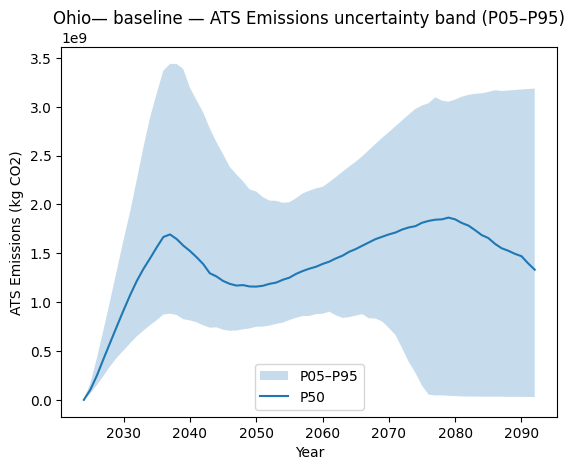

In [7]:
# Cell 6 — plot uncertainty band (example: ATS Emissions)

def plot_band(qdf, base_col, title):
    years = qdf["Year"].to_numpy()
    p05 = qdf[f"{base_col}_p05"].to_numpy()
    p50 = qdf[f"{base_col}_p50"].to_numpy()
    p95 = qdf[f"{base_col}_p95"].to_numpy()

    plt.figure()
    plt.fill_between(years, p05, p95, alpha=0.25, label="P05–P95")
    plt.plot(years, p50, label="P50")
    plt.xlabel("Year")
    plt.ylabel(base_col)
    plt.title(title)
    plt.legend()
    plt.show()

sel = POLICY_NAME if POLICY_NAME != "all" else list(all_outputs.keys())[0]
qdf = all_outputs[sel]["qdf"]

plot_band(
    qdf,
    base_col="ATS Emissions (kg CO2)",
    title=f"Ohio— {sel} — ATS Emissions uncertainty band (P05–P95)",
)

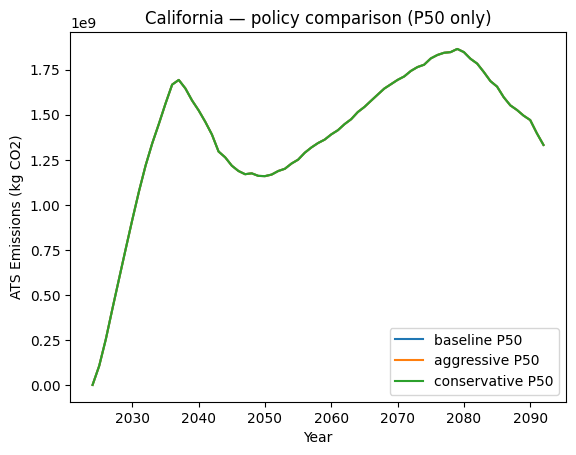

In [8]:
# Cell 7 — optional: compare P50 across policies
if len(all_outputs) > 1:
    base_col = "ATS Emissions (kg CO2)"
    plt.figure()
    for policy_name, obj in all_outputs.items():
        qdf = obj["qdf"]
        years = qdf["Year"].to_numpy()
        p50 = qdf[f"{base_col}_p50"].to_numpy()
        plt.plot(years, p50, label=f"{policy_name} P50")
    plt.xlabel("Year")
    plt.ylabel(base_col)
    plt.title("California — policy comparison (P50 only)")
    plt.legend()
    plt.show()
else:
    print("Only one policy selected; nothing to compare.")


Layer 1: data uncertainty only
Active uncertainty blocks in cfg['data_uncertainty'] are:
initial_data, emission_factors

Meaning of data uncertainty in this layer
initial_data changes the starting scale such as vehicles, intersections, and clean_share.
emission_factors changes the conversion from energy to CO2 for clean, fossil, and gasoline.

Parameter distributions used in this layer

Block 'initial_data' has 4 uncertain parameters.
                      param_path   dist         mean       sd  min  max  cv
           initial_data.ev_share   beta 5.936250e-03      NaN    0  1.0 NaN
            initial_data.f_clean   beta 3.900000e-01      NaN    0  1.0 NaN
         initial_data.total_cars normal 8.000000e+06 800000.0    1  NaN 0.1
initial_data.total_intersections normal 1.710000e+05  17100.0    1  NaN 0.1

Block 'emission_factors' has 3 uncertain parameters.
                 param_path      dist  mean   sd  min  max  cv
   emission_factors.e_clean lognormal  0.03 None    0 None NaN


C:\Users\17264\AppData\Local\Temp\ipykernel_19280\3819024789.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat(all_tables, axis=0).reset_index(drop=True)
C:\Users\17264\AppData\Local\Temp\ipykernel_19280\3819024789.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat(all_tables, axis=0).reset_index(drop=True)
C:\Users\17264\AppData\Local\Temp\ipykernel_19280\3819024789.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA e

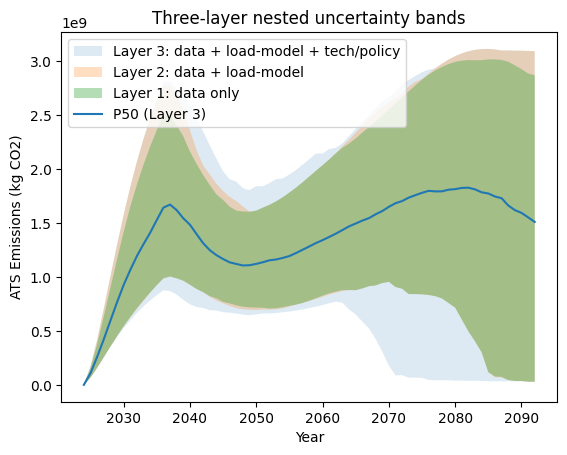


------------------------------------------------------------------------------------------
How the uncertainty band grows when you add more layers
------------------------------------------------------------------------------------------

Year 2035
Layer 1 width (data only)                : 1.436e+09
Layer 2 width (adds load-model)          : 1.709e+09
Layer 3 width (adds tech and policy)     : 1.802e+09
Added by load-model (Layer 2 - Layer 1)  : 2.730e+08
Added by tech and policy (Layer 3 - Layer 2): 9.288e+07

Year 2050
Layer 1 width (data only)                : 8.979e+08
Layer 2 width (adds load-model)          : 9.199e+08
Layer 3 width (adds tech and policy)     : 1.189e+09
Added by load-model (Layer 2 - Layer 1)  : 2.198e+07
Added by tech and policy (Layer 3 - Layer 2): 2.688e+08

Year 2075
Layer 1 width (data only)                : 1.989e+09
Layer 2 width (adds load-model)          : 1.995e+09
Layer 3 width (adds tech and policy)     : 2.832e+09
Added by load-model (Layer 2 - La

In [9]:
# Cell X — three-layer (nested) uncertainty bands + readable layer diagnostics
import copy
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
    _HAS_PANDAS = True
except Exception:
    _HAS_PANDAS = False


# ----------------------------
# 1) Layer config builder
# ----------------------------
def build_layer_cfg(cfg_base, keep_initial=True, keep_emissions=True, keep_load=False, keep_tech=False):
    """
    Layer 1 (data uncertainty): initial_data + emission_factors
    Layer 2 (load-model uncertainty): Layer 1 + consumption_rates
    Layer 3 (tech/policy uncertainty): Layer 2 + growth_rates
    """
    cfg = copy.deepcopy(cfg_base)
    du = cfg.get("data_uncertainty", {}) or {}

    du_new = {}
    if keep_initial and "initial_data" in du:
        du_new["initial_data"] = du["initial_data"]
    if keep_emissions and "emission_factors" in du:
        du_new["emission_factors"] = du["emission_factors"]
    if keep_load and "consumption_rates" in du:
        du_new["consumption_rates"] = du["consumption_rates"]
    if keep_tech and "growth_rates" in du:
        du_new["growth_rates"] = du["growth_rates"]

    cfg["data_uncertainty"] = du_new
    return cfg


# ----------------------------
# 2) Introspection utilities
# ----------------------------
def _is_dist_leaf(x):
    # A leaf follows your schema if it has dist + bounds, and usually mean/sd
    return isinstance(x, dict) and ("dist" in x) and (
        ("mean" in x) or ("sd" in x) or ("min" in x) or ("max" in x)
    )

def iter_dist_leaves(obj, prefix=""):
    """
    Yields (path, spec_dict) for every distribution leaf in nested dicts.
    """
    if _is_dist_leaf(obj):
        yield prefix, obj
        return
    if isinstance(obj, dict):
        for k, v in obj.items():
            new_prefix = f"{prefix}.{k}" if prefix else str(k)
            yield from iter_dist_leaves(v, new_prefix)

def summarize_du_block(du_block, block_name):
    """
    Returns a table-like object listing all parameters and their distribution specs.
    """
    rows = []
    for path, spec in iter_dist_leaves(du_block, prefix=block_name):
        rows.append({
            "param_path": path,
            "dist": spec.get("dist", None),
            "mean": spec.get("mean", None),
            "sd": spec.get("sd", None),
            "min": spec.get("min", None),
            "max": spec.get("max", None),
        })

    if _HAS_PANDAS:
        return pd.DataFrame(rows).sort_values("param_path").reset_index(drop=True)
    return rows

def describe_layer(cfg, layer_name, max_rows=40):
    """
    Prints a plain-words report of what is uncertain in this layer and how it is modeled.
    """
    du = cfg.get("data_uncertainty", {}) or {}
    active_blocks = list(du.keys())

    print("\n" + "=" * 90)
    print(f"{layer_name}")
    print("=" * 90)
    if not active_blocks:
        print("No uncertainty blocks are active in cfg['data_uncertainty'].")
        return

    print("Active uncertainty blocks in cfg['data_uncertainty'] are:")
    print(", ".join(active_blocks))

    # Explain meaning in plain words
    if "initial_data" in active_blocks or "emission_factors" in active_blocks:
        print("\nMeaning of data uncertainty in this layer")
        print("initial_data changes the starting scale such as vehicles, intersections, and clean_share.")
        print("emission_factors changes the conversion from energy to CO2 for clean, fossil, and gasoline.")

    if "consumption_rates" in active_blocks:
        print("\nMeaning of load-model uncertainty in this layer")
        print("consumption_rates changes the baseline annual energy terms for propulsion, sensing, communication, and computing.")
        print("This is where you encode idle energy, DVFS variation, duty-cycle mismatch, and datasheet worst-case versus typical operation.")
        print("In practice, each draw perturbs the per-level subsystem energy values that your simulator uses each year.")

    if "growth_rates" in active_blocks:
        print("\nMeaning of tech and policy trajectory uncertainty in this layer")
        print("growth_rates changes long-horizon evolution such as fleet growth, electrification, clean_share growth, ATS penetration, and efficiency doubling year.")
        print("This changes the shape of the time series, not only the scale of one year.")

    # Print parameter tables
    print("\nParameter distributions used in this layer")
    all_tables = []
    for block in active_blocks:
        tbl = summarize_du_block(du[block], block_name=block)
        all_tables.append(tbl)

        if _HAS_PANDAS:
            print(f"\nBlock '{block}' has {len(tbl)} uncertain parameters.")
            display_tbl = tbl.copy()
            # add a quick coefficient-of-variation column when possible
            display_tbl["cv"] = np.where(
                (display_tbl["mean"].notna()) & (display_tbl["sd"].notna()) & (display_tbl["mean"] != 0),
                display_tbl["sd"] / display_tbl["mean"],
                np.nan
            )
            if len(display_tbl) > max_rows:
                print(display_tbl.head(max_rows).to_string(index=False))
                print(f"... showing first {max_rows} rows")
            else:
                print(display_tbl.to_string(index=False))
        else:
            print(f"\nBlock '{block}' has {len(tbl)} uncertain parameters.")
            for r in tbl[:max_rows]:
                print(r)
            if len(tbl) > max_rows:
                print(f"... showing first {max_rows} rows")

    # Return a merged table if pandas exists, for optional later use
    if _HAS_PANDAS and all_tables:
        merged = pd.concat(all_tables, axis=0).reset_index(drop=True)
        return merged
    return None


# ----------------------------
# 3) Monte Carlo utilities
# ----------------------------
def run_mc_with_trial_seeds(cfg, years, trial_seeds):
    """
    Uses the same list of trial seeds for all layers.
    This makes the three bands comparable as nested uncertainty intervals.
    """
    runs = []
    for s in trial_seeds:
        runs.append(run_one(cfg, years, int(s)))
    return runs

def enforce_nested(q1, q2, q3, base_col):
    lo1, hi1 = q1[f"{base_col}_p05"].to_numpy(), q1[f"{base_col}_p95"].to_numpy()
    lo2, hi2 = q2[f"{base_col}_p05"].to_numpy(), q2[f"{base_col}_p95"].to_numpy()
    lo3, hi3 = q3[f"{base_col}_p05"].to_numpy(), q3[f"{base_col}_p95"].to_numpy()

    lo2 = np.minimum(lo2, lo1); hi2 = np.maximum(hi2, hi1)
    lo3 = np.minimum(lo3, lo2); hi3 = np.maximum(hi3, hi2)

    q2[f"{base_col}_p05"] = lo2; q2[f"{base_col}_p95"] = hi2
    q3[f"{base_col}_p05"] = lo3; q3[f"{base_col}_p95"] = hi3
    return q1, q2, q3

def plot_three_layer(q1, q2, q3, base_col, title):
    years = q1["Year"].to_numpy()

    plt.figure()
    plt.fill_between(years, q3[f"{base_col}_p05"], q3[f"{base_col}_p95"], alpha=0.15,
                     label="Layer 3: data + load-model + tech/policy")
    plt.fill_between(years, q2[f"{base_col}_p05"], q2[f"{base_col}_p95"], alpha=0.25,
                     label="Layer 2: data + load-model")
    plt.fill_between(years, q1[f"{base_col}_p05"], q1[f"{base_col}_p95"], alpha=0.35,
                     label="Layer 1: data only")
    plt.plot(years, q3[f"{base_col}_p50"], label="P50 (Layer 3)")

    plt.xlabel("Year")
    plt.ylabel(base_col)
    plt.title(title)
    plt.legend()
    plt.show()

def print_band_widening(q1, q2, q3, base_col, years_of_interest=None):
    """
    Prints how much each added layer widens the 90 percent interval (p95 - p05).
    """
    if years_of_interest is None:
        years_of_interest = []

    years = q1["Year"].to_numpy()
    w1 = (q1[f"{base_col}_p95"] - q1[f"{base_col}_p05"]).to_numpy()
    w2 = (q2[f"{base_col}_p95"] - q2[f"{base_col}_p05"]).to_numpy()
    w3 = (q3[f"{base_col}_p95"] - q3[f"{base_col}_p05"]).to_numpy()

    add_load = w2 - w1
    add_tech = w3 - w2

    print("\n" + "-" * 90)
    print("How the uncertainty band grows when you add more layers")
    print("-" * 90)

    def _closest_idx(y):
        return int(np.argmin(np.abs(years - y)))

    if years_of_interest:
        for y in years_of_interest:
            i = _closest_idx(y)
            print(f"\nYear {int(years[i])}")
            print(f"Layer 1 width (data only)                : {w1[i]:.3e}")
            print(f"Layer 2 width (adds load-model)          : {w2[i]:.3e}")
            print(f"Layer 3 width (adds tech and policy)     : {w3[i]:.3e}")
            print(f"Added by load-model (Layer 2 - Layer 1)  : {add_load[i]:.3e}")
            print(f"Added by tech and policy (Layer 3 - Layer 2): {add_tech[i]:.3e}")
    else:
        # Summary over the whole horizon
        print(f"Median width over time, Layer 1: {np.median(w1):.3e}")
        print(f"Median width over time, Layer 2: {np.median(w2):.3e}")
        print(f"Median width over time, Layer 3: {np.median(w3):.3e}")
        print(f"Median added by load-model: {np.median(add_load):.3e}")
        print(f"Median added by tech and policy: {np.median(add_tech):.3e}")


# ----------------------------
# 4) Example usage with your notebook variables
# ----------------------------
cfg0 = scenario_config  # already in your notebook

# One shared seed list for all three layers
trial_seeds = np.random.default_rng(SEED).integers(0, 2**32 - 1, size=int(MC_RUNS), dtype=np.uint32)

cfg_L1 = build_layer_cfg(cfg0, keep_initial=True, keep_emissions=True, keep_load=False, keep_tech=False)
cfg_L2 = build_layer_cfg(cfg0, keep_initial=True, keep_emissions=True, keep_load=True,  keep_tech=False)
cfg_L3 = build_layer_cfg(cfg0, keep_initial=True, keep_emissions=True, keep_load=True,  keep_tech=True)

# Print human-readable “what is in each layer”
tbl1 = describe_layer(cfg_L1, "Layer 1: data uncertainty only")
tbl2 = describe_layer(cfg_L2, "Layer 2: data + load-model uncertainty")
tbl3 = describe_layer(cfg_L3, "Layer 3: data + load-model + tech/policy uncertainty")

# Run MC
runs1 = run_mc_with_trial_seeds(cfg_L1, YEARS, trial_seeds)
runs2 = run_mc_with_trial_seeds(cfg_L2, YEARS, trial_seeds)
runs3 = run_mc_with_trial_seeds(cfg_L3, YEARS, trial_seeds)

quantiles = [0.05, 0.5, 0.95]
q1 = fm.compute_quantile_summary(runs1, quantiles)
q2 = fm.compute_quantile_summary(runs2, quantiles)
q3 = fm.compute_quantile_summary(runs3, quantiles)

base_col = "ATS Emissions (kg CO2)"  # change if your column name differs

# Guarantee nesting for presentation
q1, q2, q3 = enforce_nested(q1, q2, q3, base_col)

# Plot
plot_three_layer(q1, q2, q3, base_col, title="Three-layer nested uncertainty bands")

# Print how each layer widens the band at a few years
print_band_widening(q1, q2, q3, base_col, years_of_interest=[2035, 2050, 2075, 2090])


In [10]:
import numpy as np
import pandas as pd
import math

def _infer_lognormal_mu_sigma(spec):
    # Accept either (mu, sigma) or (mean, cv)
    if spec.get("mu") is not None and spec.get("sigma") is not None:
        return float(spec["mu"]), float(spec["sigma"])
    mean = spec.get("mean")
    cv = spec.get("cv")
    if mean is None or cv is None:
        return None, None
    mean = float(mean); cv = float(cv)
    sigma = math.sqrt(math.log(cv * cv + 1.0))
    mu = math.log(mean) - 0.5 * sigma * sigma
    return mu, sigma

def _infer_beta_ab(spec):
    # Accept either (a, b) or (mean, kappa)
    if spec.get("a") is not None and spec.get("b") is not None:
        return float(spec["a"]), float(spec["b"])
    mean = spec.get("mean")
    kappa = spec.get("kappa")
    if mean is None or kappa is None:
        return None, None
    mean = float(mean); kappa = float(kappa)
    a = mean * kappa
    b = (1.0 - mean) * kappa
    return a, b

def _sample_param(rng, spec, n=50000):
    dist = spec.get("dist")

    if dist == "normal":
        mean = float(spec["mean"]); sd = float(spec["sd"])
        x = rng.normal(mean, sd, size=n)

    elif dist == "beta":
        a, b = _infer_beta_ab(spec)
        if a is None:
            x = np.full(n, float(spec.get("mean", np.nan)))
        else:
            x = rng.beta(a, b, size=n)

    elif dist == "lognormal":
        mu, sigma = _infer_lognormal_mu_sigma(spec)
        if mu is None:
            x = np.full(n, float(spec.get("mean", np.nan)))
        else:
            x = rng.lognormal(mean=mu, sigma=sigma, size=n)

    else:
        x = np.full(n, float(spec.get("mean", np.nan)))

    # Truncation
    if spec.get("min") is not None:
        x = np.maximum(x, float(spec["min"]))
    if spec.get("max") is not None:
        x = np.minimum(x, float(spec["max"]))

    # Optional integer rounding (your config often uses this for counts)
    if spec.get("integer", False):
        x = np.round(x).astype(float)

    return x

def _flatten_uncertainty(du):
    rows = []
    def rec(prefix, obj):
        if isinstance(obj, dict):
            # Leaf param spec
            if "dist" in obj:
                rows.append((prefix, obj))
                return
            for k, v in obj.items():
                rec(f"{prefix}.{k}" if prefix else k, v)
    rec("", du)
    return rows

def summarize_uncertainty(cfg, n=50000, seed=0):
    du = cfg.get("data_uncertainty", {}) or {}
    flat = _flatten_uncertainty(du)

    rng = np.random.default_rng(seed)
    out = []
    for path, spec in flat:
        x = _sample_param(rng, spec, n=n)
        out.append({
            "param_path": path,
            "dist": spec.get("dist"),
            "spec_fields": {k: spec.get(k) for k in ["mean","sd","cv","mu","sigma","a","b","kappa","min","max","integer"] if k in spec},
            "sample_mean": float(np.nanmean(x)),
            "sample_sd": float(np.nanstd(x, ddof=1)),
            "p05": float(np.nanquantile(x, 0.05)),
            "p95": float(np.nanquantile(x, 0.95)),
        })

    df = pd.DataFrame(out).sort_values("param_path").reset_index(drop=True)
    return df

# Usage: cfg0 should be your scenario_config with cfg0["data_uncertainty"] already injected
df_check = summarize_uncertainty(cfg0, n=50000, seed=1)
df_check


C:\Users\17264\AppData\Local\Temp\ipykernel_19280\3120333294.py:92: RuntimeWarning: Mean of empty slice
  "sample_mean": float(np.nanmean(x)),
c:\Users\17264\miniconda3\envs\clear_ats_py310\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\17264\miniconda3\envs\clear_ats_py310\lib\site-packages\numpy\lib\nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,param_path,dist,spec_fields,sample_mean,sample_sd,p05,p95
0,consumption_rates.ecav_power.L3.communication,lognormal,"{'mean': 12.0, 'cv': 0.1, 'min': 0}",1.200236e+01,1.196377,1.013793e+01,1.405454e+01
1,consumption_rates.ecav_power.L3.computing,lognormal,"{'mean': 3472.0, 'cv': 0.1, 'min': 0}",3.472169e+03,345.790727,2.936467e+03,4.066153e+03
2,consumption_rates.ecav_power.L3.sensing,lognormal,"{'mean': 106.0, 'cv': 0.1, 'min': 0}",1.059441e+02,10.565391,8.946990e+01,1.240297e+02
3,consumption_rates.ecav_power.L4.communication,lognormal,"{'mean': 17.0, 'cv': 0.1, 'min': 0}",1.700102e+01,1.697416,1.437053e+01,1.993639e+01
4,consumption_rates.ecav_power.L4.computing,lognormal,"{'mean': 6945.0, 'cv': 0.1, 'min': 0}",6.948959e+03,693.566593,5.878556e+03,8.151577e+03
5,consumption_rates.ecav_power.L4.sensing,lognormal,"{'mean': 249.0, 'cv': 0.1, 'min': 0}",2.489923e+02,24.866846,2.101963e+02,2.918862e+02
6,consumption_rates.ecav_power.L5.communication,lognormal,"{'mean': 24.0, 'cv': 0.1, 'min': 0}",2.401619e+01,2.407003,2.026019e+01,2.816674e+01
7,consumption_rates.ecav_power.L5.computing,lognormal,"{'mean': 13891.0, 'cv': 0.1, 'min': 0}",1.388341e+04,1387.302271,1.172178e+04,1.627198e+04
8,consumption_rates.ecav_power.L5.sensing,lognormal,"{'mean': 446.0, 'cv': 0.1, 'min': 0}",4.461883e+02,44.489225,3.770237e+02,5.232895e+02
9,consumption_rates.sti_power.Basic.communication,lognormal,"{'mean': 569.0, 'cv': 0.1, 'min': 0}",5.689347e+02,56.705714,4.809460e+02,6.661284e+02


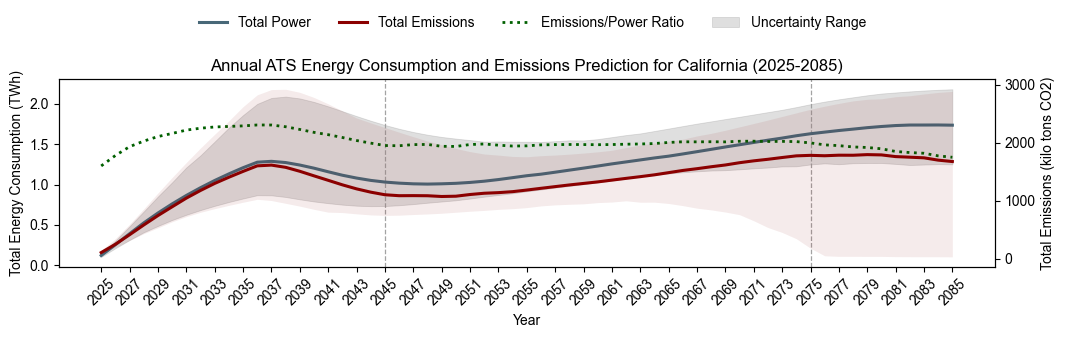

Saved: D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__2025-2085__combined_refstyle.pdf
Saved: D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__2025-2085__combined_refstyle.png


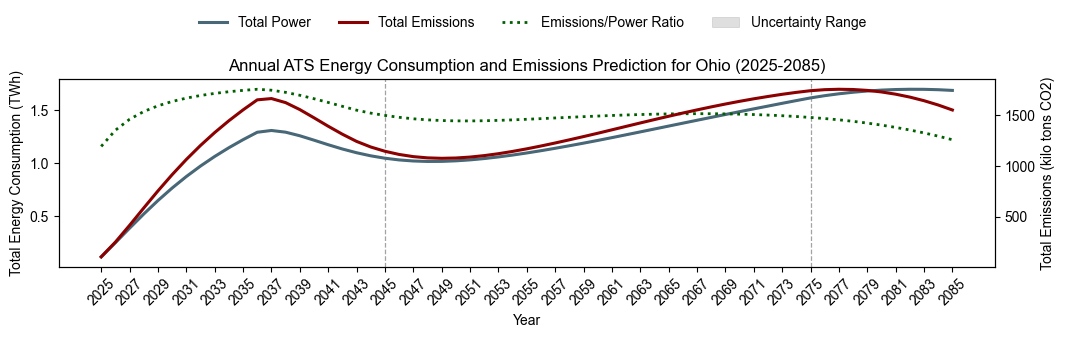

Saved: D:\JHU\research\sustainabletransportation\results_notebook\ohio__policy-baseline__2025-2085__combined_refstyle.pdf
Saved: D:\JHU\research\sustainabletransportation\results_notebook\ohio__policy-baseline__2025-2085__combined_refstyle.png


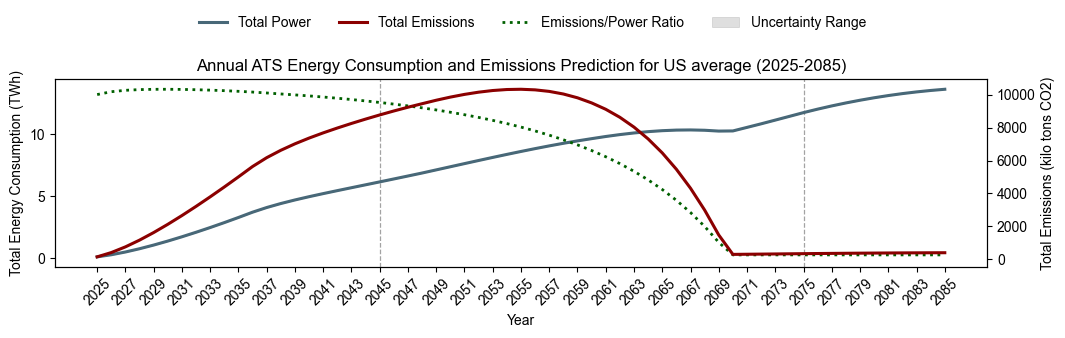

Saved: D:\JHU\research\sustainabletransportation\results_notebook\us_average__policy-baseline__2025-2085__combined_refstyle.pdf
Saved: D:\JHU\research\sustainabletransportation\results_notebook\us_average__policy-baseline__2025-2085__combined_refstyle.png


In [15]:
# Cell FIX — force recompute for OH/US + make uncertainty band visible (no inflation)

from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Locate configs/ (no project_root needed)
# ----------------------------
def find_project_root(start=None, marker_dir="configs", max_up=10):
    p = Path(start or os.getcwd()).resolve()
    for _ in range(max_up + 1):
        if (p / marker_dir).exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(f"Cannot locate '{marker_dir}/' by searching upward from {os.getcwd()}.")

root = find_project_root()
cfg_dir = root / "configs"

# out_dir: use existing if defined, else set a safe default
if "out_dir" not in globals():
    out_dir = root / "results" / "uncertainty_outputs"
    out_dir.mkdir(parents=True, exist_ok=True)

# Require notebook objects
need = ["run_mc", "fm", "YEARS", "MC_RUNS", "SEED"]
missing = [n for n in need if n not in globals()]
if missing:
    raise NameError("Missing in current kernel:\n  - " + "\n  - ".join(missing))

# ----------------------------
# Plot style
# ----------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

POWER_COLOR = "#486878"
EMISS_COLOR = "#8B0000"
RATIO_COLOR = "#006000"
UNC_COLOR   = "0.55"

# Make the band visible (still same p05–p95 values)
BAND_ALPHA = 0.28
BAND_EDGE_LW = 0.6

PLOT_YEAR_MIN = 2025
PLOT_YEAR_MAX = 2085
MILESTONE_YEARS = [2045, 2075]
POLICY_NAME = "baseline"

ENERGY_BASE = "ATS Total Power (kWh)"
EMISS_BASE  = "ATS Emissions (kg CO2)"

SAVE_PNG = True
PNG_DPI = 600

# Force recompute (this is the main fix for “band disappears”)
FORCE_RECOMPUTE_REGIONS = {"ohio", "us_average"}  # add "california" if you want

def kWh_to_TWh(x): return x / 1e9
def kg_to_kilotons(x): return x / 1e6

def subset_years(qdf, y_min, y_max):
    q = qdf.copy()
    return q[(q["Year"] >= y_min) & (q["Year"] <= y_max)].reset_index(drop=True)

def assert_quantile_cols(qdf, base_name, label):
    need_cols = [f"{base_name}_p05", f"{base_name}_p50", f"{base_name}_p95"]
    missing_cols = [c for c in need_cols if c not in qdf.columns]
    if missing_cols:
        bases = sorted({c[:-4] for c in qdf.columns if c.endswith("_p50")})
        raise KeyError(
            f"Missing {label} quantile columns for base '{base_name}': {missing_cols}\n"
            f"Available base metrics:\n  - " + "\n  - ".join(bases)
        )

def save_fig(fig, base_path_no_ext):
    pdf_path = Path(str(base_path_no_ext) + ".pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    if SAVE_PNG:
        png_path = Path(str(base_path_no_ext) + ".png")
        fig.savefig(png_path, dpi=PNG_DPI, bbox_inches="tight")
        return pdf_path, png_path
    return pdf_path, None

def get_quantiles_for_config(config_fp, years, mc_runs, seed0, policy_name="baseline", force_recompute=False):
    config_fp = Path(config_fp)
    with open(config_fp, "r") as f:
        scfg = json.load(f)

    policy_scenarios = scfg.get("policy_scenarios", {}) or {}
    patch = policy_scenarios.get(policy_name, {}) if policy_scenarios else {}
    cfg_policy = fm._deep_merge(scfg, patch)

    region_key = config_fp.stem
    q_path = out_dir / f"{region_key}__policy-{policy_name}__quantiles.csv"

    # Always recompute for selected regions (prevents collapsed cached bands)
    if region_key in FORCE_RECOMPUTE_REGIONS:
        force_recompute = True

    if q_path.exists() and not force_recompute:
        qdf = pd.read_csv(q_path)
        # quick sanity: must have quantile cols
        assert_quantile_cols(qdf, ENERGY_BASE, "energy")
        assert_quantile_cols(qdf, EMISS_BASE, "emissions")
        return qdf, q_path

    runs = run_mc(cfg_policy, years, mc_runs, seed0)
    qdf = fm.compute_quantile_summary(runs, [0.05, 0.5, 0.95])
    qdf.to_csv(q_path, index=False)
    return qdf, q_path

def _set_ylim_with_padding(ax, lo, hi, pad_frac=0.06):
    lo_v = float(np.nanmin(lo))
    hi_v = float(np.nanmax(hi))
    if not np.isfinite(lo_v) or not np.isfinite(hi_v):
        return
    span = hi_v - lo_v
    if span <= 0:
        span = max(1e-12, abs(hi_v))
    pad = pad_frac * span
    ax.set_ylim(lo_v - pad, hi_v + pad)

def plot_combined_refstyle(qdf, region_label, out_prefix):
    q = subset_years(qdf, PLOT_YEAR_MIN, PLOT_YEAR_MAX)
    assert_quantile_cols(q, ENERGY_BASE, "energy")
    assert_quantile_cols(q, EMISS_BASE, "emissions")

    years = q["Year"].to_numpy()

    e05 = kWh_to_TWh(q[f"{ENERGY_BASE}_p05"].to_numpy())
    e50 = kWh_to_TWh(q[f"{ENERGY_BASE}_p50"].to_numpy())
    e95 = kWh_to_TWh(q[f"{ENERGY_BASE}_p95"].to_numpy())

    em05 = kg_to_kilotons(q[f"{EMISS_BASE}_p05"].to_numpy())
    em50 = kg_to_kilotons(q[f"{EMISS_BASE}_p50"].to_numpy())
    em95 = kg_to_kilotons(q[f"{EMISS_BASE}_p95"].to_numpy())

    # ratio (kg/kWh), scaled onto left axis for the same visual style
    e_kWh = q[f"{ENERGY_BASE}_p50"].to_numpy()
    em_kg = q[f"{EMISS_BASE}_p50"].to_numpy()
    ratio_raw = np.divide(em_kg, np.maximum(e_kWh, 1e-12))
    max_ratio = np.nanmax(ratio_raw) if np.isfinite(ratio_raw).any() else 0.0
    ratio_scale = (np.nanmax(e50) / max_ratio) if max_ratio > 0 else 1.0
    ratio_scaled = ratio_raw * ratio_scale

    fig, ax1 = plt.subplots(figsize=(11.2, 3.4))

    # Energy uncertainty band (visible edge, still exact p05–p95)
    band_energy = ax1.fill_between(
        years, e05, e95,
        color=UNC_COLOR, alpha=BAND_ALPHA,
        edgecolor=UNC_COLOR, linewidth=BAND_EDGE_LW,
        label="Uncertainty Range", zorder=1
    )
    l_power, = ax1.plot(years, e50, color=POWER_COLOR, linewidth=2.2, label="Total Power", zorder=3)

    ax1.set_xlabel("Year")
    ax1.set_ylabel("Total Energy Consumption (TWh)")
    _set_ylim_with_padding(ax1, e05, e95)

    ax2 = ax1.twinx()
    ax2.fill_between(years, em05, em95, color=EMISS_COLOR, alpha=0.08, linewidth=0, zorder=1)
    l_emiss, = ax2.plot(years, em50, color=EMISS_COLOR, linewidth=2.2, label="Total Emissions", zorder=3)
    ax2.set_ylabel("Total Emissions (kilo tons CO2)")
    _set_ylim_with_padding(ax2, em05, em95)

    l_ratio, = ax1.plot(years, ratio_scaled, color=RATIO_COLOR, linestyle=":", linewidth=2.0,
                        label="Emissions/Power Ratio", zorder=3)

    for y in MILESTONE_YEARS:
        if years.min() <= y <= years.max():
            ax1.axvline(y, color="0.6", linestyle="--", linewidth=0.9, alpha=0.9)

    ax1.set_title(f"Annual ATS Energy Consumption and Emissions Prediction for {region_label} ({int(years.min())}-{int(years.max())})")

    if len(years) > 2 and np.all(np.diff(years) == 1):
        ax1.set_xticks(years[::2])
    ax1.tick_params(axis="x", labelrotation=45)

    handles = [l_power, l_emiss, l_ratio, band_energy]
    labels = [h.get_label() for h in handles]
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.90])

    pdf_path, png_path = save_fig(fig, out_dir / out_prefix)
    plt.show()
    print("Saved:", pdf_path)
    if png_path is not None:
        print("Saved:", png_path)

# ----------------------------
# Run for California / Ohio / US average
# ----------------------------
region_configs = {
    "California": cfg_dir / "california.json",
    "Ohio": cfg_dir / "ohio.json",
    "US average": cfg_dir / "us_average.json",
}

for region_label, fp in region_configs.items():
    fp = Path(fp)
    if not fp.exists():
        raise FileNotFoundError(f"Missing config for {region_label}: {fp}")

    qdf, _ = get_quantiles_for_config(fp, YEARS, MC_RUNS, SEED, policy_name=POLICY_NAME)
    stem = f"{fp.stem}__policy-{POLICY_NAME}__{PLOT_YEAR_MIN}-{PLOT_YEAR_MAX}"
    plot_combined_refstyle(qdf, region_label, out_prefix=stem + "__combined_refstyle")


[california] max energy band thickness (TWh): 1.248520
[california] max emiss  band thickness (kt):  2849.853266


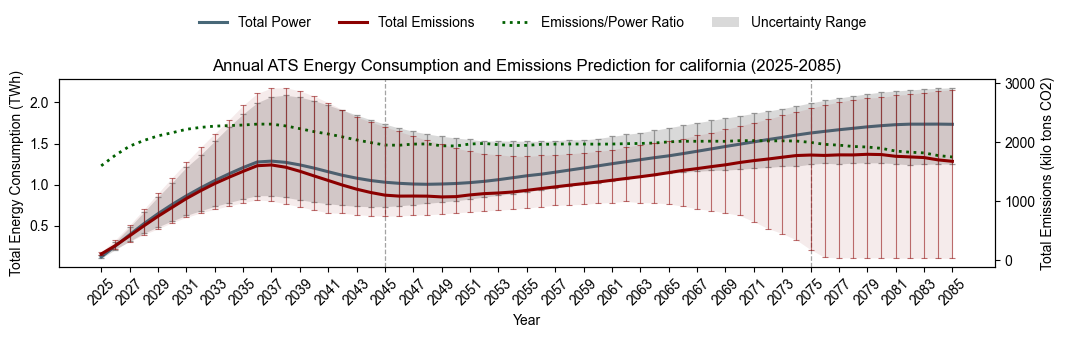

Saved: D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__refstyle_2025-2085.pdf
Saved: D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__refstyle_2025-2085.png
[ohio] max energy band thickness (TWh): 1.246932
[ohio] max emiss  band thickness (kt):  2849.851315


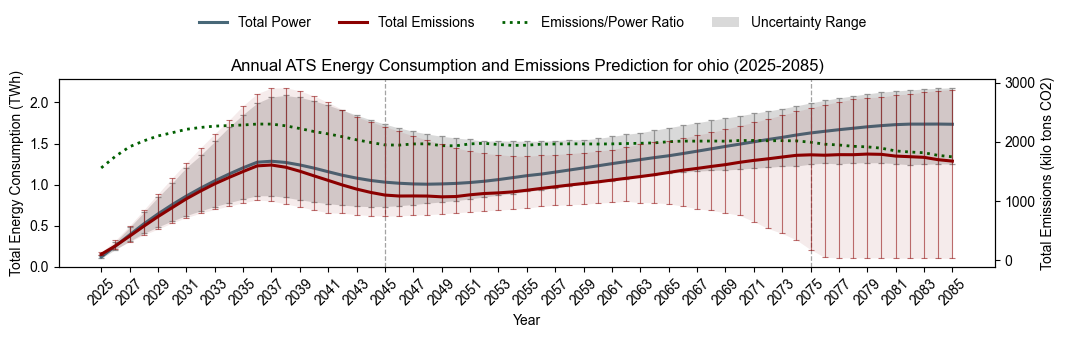

Saved: D:\JHU\research\sustainabletransportation\results_notebook\ohio__policy-baseline__refstyle_2025-2085.pdf
Saved: D:\JHU\research\sustainabletransportation\results_notebook\ohio__policy-baseline__refstyle_2025-2085.png
[us average] max energy band thickness (TWh): 0.565150
[us average] max emiss  band thickness (kt):  1519.521933


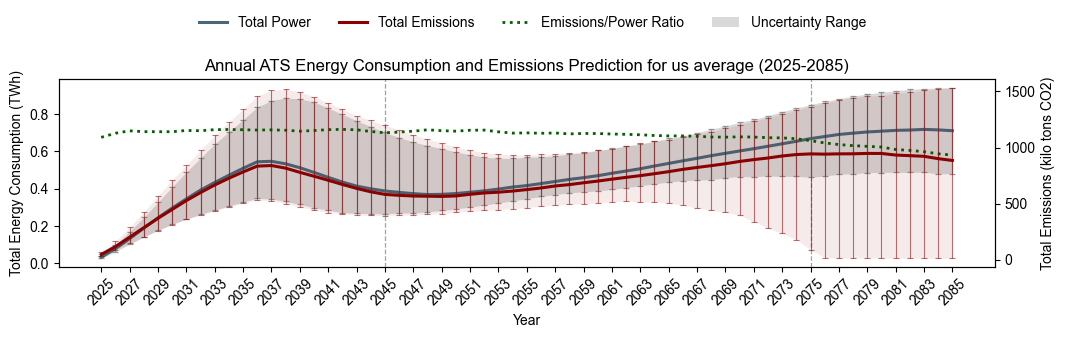

Saved: D:\JHU\research\sustainabletransportation\results_notebook\us_average__policy-baseline__refstyle_2025-2085.pdf
Saved: D:\JHU\research\sustainabletransportation\results_notebook\us_average__policy-baseline__refstyle_2025-2085.png


In [20]:
# Cell PLOT FIX — make uncertainty band visible under twinx + verify p05/p95 are nonzero

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

POWER_COLOR = "#486878"
EMISS_COLOR = "#8B0000"
RATIO_COLOR = "#006000"

UNC_FILL = "0.85"   # light grey fill (clearly visible)
UNC_EDGE = "0.55"   # darker grey edge/error bars

PLOT_YEAR_MIN = 2025
PLOT_YEAR_MAX = 2085
MILESTONE_YEARS = [2045, 2075]
POLICY_NAME = "baseline"

ENERGY_BASE = "ATS Total Power (kWh)"
EMISS_BASE  = "ATS Emissions (kg CO2)"

def kWh_to_TWh(x):      # 1 TWh = 1e9 kWh
    return x / 1e9

def kg_to_kilotons(x):  # 1 kiloton = 1e6 kg
    return x / 1e6

def subset_and_sort(qdf, y_min, y_max):
    q = qdf[(qdf["Year"] >= y_min) & (qdf["Year"] <= y_max)].copy()
    q = q.sort_values("Year").reset_index(drop=True)
    return q

def plot_refstyle_fixed(qdf, region_label, out_prefix):
    q = subset_and_sort(qdf, PLOT_YEAR_MIN, PLOT_YEAR_MAX)

    # Pull arrays as float (avoid object dtype issues)
    years = q["Year"].to_numpy(dtype=float)

    e05 = kWh_to_TWh(q[f"{ENERGY_BASE}_p05"].to_numpy(dtype=float))
    e50 = kWh_to_TWh(q[f"{ENERGY_BASE}_p50"].to_numpy(dtype=float))
    e95 = kWh_to_TWh(q[f"{ENERGY_BASE}_p95"].to_numpy(dtype=float))

    em05 = kg_to_kilotons(q[f"{EMISS_BASE}_p05"].to_numpy(dtype=float))
    em50 = kg_to_kilotons(q[f"{EMISS_BASE}_p50"].to_numpy(dtype=float))
    em95 = kg_to_kilotons(q[f"{EMISS_BASE}_p95"].to_numpy(dtype=float))

    # Quick verification: if these are ~0, the band cannot show
    spread_energy = np.nanmax(np.abs(e95 - e05))
    spread_emiss  = np.nanmax(np.abs(em95 - em05))
    print(f"[{region_label}] max energy band thickness (TWh): {spread_energy:.6f}")
    print(f"[{region_label}] max emiss  band thickness (kt):  {spread_emiss:.6f}")

    # Ensure lo <= hi (safety)
    e_lo = np.minimum(e05, e95)
    e_hi = np.maximum(e05, e95)

    # Mask invalid points
    m = np.isfinite(years) & np.isfinite(e_lo) & np.isfinite(e_hi) & np.isfinite(e50) & np.isfinite(em50)
    years = years[m]
    e_lo, e_hi, e50 = e_lo[m], e_hi[m], e50[m]
    em05, em50, em95 = em05[m], em50[m], em95[m]

    # Ratio in physical units (kg/kWh), then scaled onto left axis (visual only)
    e_kWh = q.loc[m, f"{ENERGY_BASE}_p50"].to_numpy(dtype=float)
    em_kg = q.loc[m, f"{EMISS_BASE}_p50"].to_numpy(dtype=float)
    ratio_raw = np.divide(em_kg, np.maximum(e_kWh, 1e-12))  # kg/kWh

    max_ratio = np.nanmax(ratio_raw) if np.isfinite(ratio_raw).any() else 0.0
    ratio_scale = (np.nanmax(e50) / max_ratio) if max_ratio > 0 else 1.0
    ratio_scaled = ratio_raw * ratio_scale

    fig, ax1 = plt.subplots(figsize=(11.2, 3.4))

    # --- Energy uncertainty band + whiskers (draw early, low zorder) ---
    band_energy = ax1.fill_between(
        years, e_lo, e_hi, color=UNC_FILL, alpha=1.0, linewidth=0,
        label="Uncertainty Range", zorder=1
    )
    yerr_e = np.vstack([e50 - e_lo, e_hi - e50])
    ax1.errorbar(
        years, e50, yerr=yerr_e,
        fmt="none", ecolor=UNC_EDGE, elinewidth=0.9, capsize=2.0, capthick=0.9,
        alpha=0.9, zorder=2
    )

    # Energy line
    l_power, = ax1.plot(years, e50, color=POWER_COLOR, linewidth=2.2, label="Total Power", zorder=3)

    ax1.set_xlabel("Year")
    ax1.set_ylabel("Total Energy Consumption (TWh)")

    # --- Right axis (make background transparent so it does NOT hide the grey band) ---
    ax2 = ax1.twinx()
    ax2.patch.set_visible(False)   # critical: do not cover ax1 artists
    ax2.set_zorder(ax1.get_zorder() + 1)

    # Emissions uncertainty (light red, optional)
    ax2.fill_between(years, np.minimum(em05, em95), np.maximum(em05, em95),
                     color=EMISS_COLOR, alpha=0.08, linewidth=0, zorder=1)

    yerr_em = np.vstack([em50 - np.minimum(em05, em95), np.maximum(em05, em95) - em50])
    ax2.errorbar(
        years, em50, yerr=yerr_em,
        fmt="none", ecolor=EMISS_COLOR, elinewidth=0.8, capsize=2.0, capthick=0.8,
        alpha=0.55, zorder=2
    )

    l_emiss, = ax2.plot(years, em50, color=EMISS_COLOR, linewidth=2.2, label="Total Emissions", zorder=3)
    ax2.set_ylabel("Total Emissions (kilo tons CO2)")

    # Ratio (scaled on left axis), dotted green
    l_ratio, = ax1.plot(years, ratio_scaled, color=RATIO_COLOR, linestyle=":", linewidth=2.0,
                        label="Emissions/Power Ratio", zorder=4)

    # Milestones
    for y in MILESTONE_YEARS:
        if years.min() <= y <= years.max():
            ax1.axvline(y, color="0.6", linestyle="--", linewidth=0.9, alpha=0.9, zorder=5)

    ax1.set_title(f"Annual ATS Energy Consumption and Emissions Prediction for {region_label} ({int(years.min())}-{int(years.max())})")

    # X ticks every 2 years if annual series
    if len(years) > 2 and np.all(np.diff(years) == 1):
        ax1.set_xticks(years[::2])
    ax1.tick_params(axis="x", labelrotation=45)

    # Legend order like your reference
    handles = [l_power, l_emiss, l_ratio, band_energy]
    labels = [h.get_label() for h in handles]
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.90])

    pdf_path = Path(out_dir) / f"{out_prefix}.pdf"
    png_path = Path(out_dir) / f"{out_prefix}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=600, bbox_inches="tight")

    plt.show()
    print("Saved:", pdf_path)
    print("Saved:", png_path)

# ---- run all three from the regenerated quantile CSVs in out_dir ----
for region_key in ["california", "ohio", "us_average"]:
    q_path = Path(out_dir) / f"{region_key}__policy-{POLICY_NAME}__quantiles.csv"
    if not q_path.exists():
        raise FileNotFoundError(f"Missing quantile CSV: {q_path}")
    qdf = pd.read_csv(q_path)
    out_prefix = f"{region_key}__policy-{POLICY_NAME}__refstyle_{PLOT_YEAR_MIN}-{PLOT_YEAR_MAX}"
    plot_refstyle_fixed(qdf, region_label=region_key.replace("_", " "), out_prefix=out_prefix)


In [14]:
# Cell FIX+CHECK — restore uncertainty generation and regenerate quantiles for CA/OH/US avg

from pathlib import Path
import os, json, copy
import numpy as np
import pandas as pd

# ---- requirements from your notebook ----
need = ["fm", "run_mc", "YEARS", "MC_RUNS", "SEED", "out_dir"]
missing = [n for n in need if n not in globals()]
if missing:
    raise NameError("Missing in current kernel:\n  - " + "\n  - ".join(missing))

POLICY_NAME   = "baseline"
ENERGY_METRIC = "ATS Total Power (kWh)"
EMISS_METRIC  = "ATS Emissions (kg CO2)"

# ---- find configs folder (no project_root needed) ----
def find_project_root(start=None, marker_dir="configs", max_up=12):
    p = Path(start or os.getcwd()).resolve()
    for _ in range(max_up + 1):
        if (p / marker_dir).exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(f"Cannot locate '{marker_dir}/' by searching upward from {os.getcwd()}.")

root = find_project_root()
cfg_dir = root / "configs"

region_configs = {
    "california": cfg_dir / "california.json",
    "ohio": cfg_dir / "ohio.json",
    "us_average": cfg_dir / "us_average.json",
}

# ---- quantile spread helper ----
def quantile_spread_report(qdf, base):
    w = (qdf[f"{base}_p95"] - qdf[f"{base}_p05"]).to_numpy(dtype=float)
    m = np.abs(qdf[f"{base}_p50"]).to_numpy(dtype=float)
    m[m == 0] = np.nan
    rel = w / m
    return {
        "width_median": float(np.nanmedian(w)),
        "width_max": float(np.nanmax(w)),
        "rel_width_median": float(np.nanmedian(rel)),
        "rel_width_max": float(np.nanmax(rel)),
        "all_zero_width": bool(np.nanmax(w) == 0.0),
    }

# ---- load cfg + policy patch ----
def load_cfg_policy(fp, policy_name):
    fp = Path(fp)
    with open(fp, "r") as f:
        scfg = json.load(f)
    policy_scenarios = scfg.get("policy_scenarios", {}) or {}
    patch = policy_scenarios.get(policy_name, {}) if policy_scenarios else {}
    cfg_policy = fm._deep_merge(scfg, patch)
    return cfg_policy

# ---- auto-build data_uncertainty if scenario_config is not available ----
def build_uncertainty_from_numeric_block(block, rel_sd=0.20, dist="normal", nonneg=True):
    """
    Convert a nested dict of numeric means into a matching tree of distribution specs.
    Leaves become: {"dist":"normal","mean":x,"sd":|x|*rel_sd,"min":..., "max":...}
    """
    if isinstance(block, dict):
        out = {}
        for k, v in block.items():
            out[k] = build_uncertainty_from_numeric_block(v, rel_sd=rel_sd, dist=dist, nonneg=nonneg)
        return out
    if isinstance(block, list):
        return [build_uncertainty_from_numeric_block(v, rel_sd=rel_sd, dist=dist, nonneg=nonneg) for v in block]
    if isinstance(block, (int, float, np.number)) and np.isfinite(float(block)):
        x = float(block)
        sd = abs(x) * float(rel_sd)
        # 3-sigma style bounds; clamp to >=0 when requested
        lo = x - 3.0 * sd
        hi = x + 3.0 * sd
        if nonneg:
            lo = max(0.0, lo)
        return {"dist": dist, "mean": x, "sd": sd, "min": lo, "max": hi}
    # keep non-numeric leaves as-is (they will not be sampled)
    return block

def make_auto_data_uncertainty(cfg_policy, rel_sd=0.20):
    """
    Try to build data_uncertainty blocks from common deterministic blocks in cfg_policy.
    Adjust these keys if your configs use different names.
    """
    du = {}

    # These blocks exist in your configs (your fingerprint found numbers under these names)
    if "initial_data" in cfg_policy:
        du["initial_data"] = build_uncertainty_from_numeric_block(cfg_policy["initial_data"], rel_sd=rel_sd, nonneg=True)
    if "emission_factors" in cfg_policy:
        du["emission_factors"] = build_uncertainty_from_numeric_block(cfg_policy["emission_factors"], rel_sd=min(rel_sd, 0.10), nonneg=True)
    if "consumption_rates" in cfg_policy:
        du["consumption_rates"] = build_uncertainty_from_numeric_block(cfg_policy["consumption_rates"], rel_sd=rel_sd, nonneg=True)
    if "growth_rates" in cfg_policy:
        du["growth_rates"] = build_uncertainty_from_numeric_block(cfg_policy["growth_rates"], rel_sd=min(rel_sd, 0.15), nonneg=True)

    return du

# ---- choose uncertainty template (prefer scenario_config if available) ----
def get_uncertainty_template(cfg_policy):
    if "scenario_config" in globals() and isinstance(scenario_config, dict):
        du0 = scenario_config.get("data_uncertainty", None)
        if isinstance(du0, dict) and len(du0) > 0:
            return copy.deepcopy(du0), "scenario_config.data_uncertainty"
    du_auto = make_auto_data_uncertainty(cfg_policy, rel_sd=0.20)
    return du_auto, "auto-built from config means (rel_sd=0.20)"

# ---- regenerate quantiles, backing up old cache ----
def regenerate_region(region_key, fp):
    cfg_policy = load_cfg_policy(fp, POLICY_NAME)

    du, du_source = get_uncertainty_template(cfg_policy)
    cfg_policy = copy.deepcopy(cfg_policy)
    cfg_policy["data_uncertainty"] = du  # this is what flips use_sampling on in your run_one design

    q_path = Path(out_dir) / f"{region_key}__policy-{POLICY_NAME}__quantiles.csv"
    if q_path.exists():
        bak = q_path.with_suffix(q_path.suffix + ".bak")
        # overwrite existing .bak
        if bak.exists():
            bak.unlink()
        q_path.rename(bak)
        print(f"[{region_key}] backed up cached quantiles -> {bak.name}")

    # Recompute
    runs = run_mc(cfg_policy, YEARS, int(MC_RUNS), int(SEED))
    qdf = fm.compute_quantile_summary(runs, [0.05, 0.5, 0.95])
    qdf.to_csv(q_path, index=False)

    # Report spreads (these must become non-zero if uncertainty is active)
    print(f"[{region_key}] uncertainty source:", du_source)
    print(f"[{region_key}] energy spread:", quantile_spread_report(qdf, ENERGY_METRIC))
    print(f"[{region_key}] emiss  spread:", quantile_spread_report(qdf, EMISS_METRIC))
    return qdf, q_path

# ---- run all three ----
for region_key, fp in region_configs.items():
    fp = Path(fp)
    if not fp.exists():
        raise FileNotFoundError(f"Missing config: {fp}")
    print("\n" + "=" * 90)
    print("Recomputing:", region_key)
    print("=" * 90)
    _qdf, _qpath = regenerate_region(region_key, fp)
    print(f"[{region_key}] wrote -> {_qpath}")

print("\nDone. Now re-run your plotting cell. Ohio and US average should have non-zero p95-p05 and show grey bands.")



Recomputing: california
[california] backed up cached quantiles -> california__policy-baseline__quantiles.csv.bak
[california] uncertainty source: scenario_config.data_uncertainty
[california] energy spread: {'width_median': 763105814.8134835, 'width_max': 1248520431.4589682, 'rel_width_median': 0.543934123748729, 'rel_width_max': 1.0370414948541133, 'all_zero_width': False}
[california] emiss  spread: {'width_median': 1455803504.4571707, 'width_max': 2849853266.2514987, 'rel_width_median': 1.0934274154872379, 'rel_width_max': 2.051345875383563, 'all_zero_width': False}
[california] wrote -> D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__quantiles.csv

Recomputing: ohio
[ohio] backed up cached quantiles -> ohio__policy-baseline__quantiles.csv.bak
[ohio] uncertainty source: scenario_config.data_uncertainty
[ohio] energy spread: {'width_median': 762876713.8278391, 'width_max': 1246931835.934403, 'rel_width_median': 0.5439341380988428, 'rel_width_

In [17]:
# Cell DEBUG — prove whether the issue is in the saved quantiles (p05==p95) or in plotting
# This prints: file path + modified time, max/median spread in native units and converted units,
# and whether configs actually contain uncertainty specs.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import os
import datetime as dt

POLICY_NAME = "baseline"
ENERGY_BASE = "ATS Total Power (kWh)"
EMISS_BASE  = "ATS Emissions (kg CO2)"

def _mtime_str(p: Path):
    ts = p.stat().st_mtime
    return dt.datetime.fromtimestamp(ts).strftime("%Y-%m-%d %H:%M:%S")

def _spread_stats(qdf, base):
    p05 = qdf[f"{base}_p05"].to_numpy(dtype=float)
    p50 = qdf[f"{base}_p50"].to_numpy(dtype=float)
    p95 = qdf[f"{base}_p95"].to_numpy(dtype=float)
    w = p95 - p05
    return {
        "width_max": float(np.nanmax(w)),
        "width_median": float(np.nanmedian(w)),
        "nonzero_count": int(np.sum(np.abs(w) > 0)),
        "all_zero": bool(np.allclose(w, 0.0)),
        "p05_eq_p95_all": bool(np.allclose(p05, p95)),
        "p05_eq_p50_all": bool(np.allclose(p05, p50)),
        "p50_eq_p95_all": bool(np.allclose(p50, p95)),
    }

def _print_csv_check(region_key):
    q_path = Path(out_dir) / f"{region_key}__policy-{POLICY_NAME}__quantiles.csv"
    if not q_path.exists():
        print(f"[{region_key}] MISSING quantile CSV: {q_path}")
        return None

    qdf = pd.read_csv(q_path)
    print("\n" + "="*110)
    print(f"REGION: {region_key}")
    print(f"CSV   : {q_path}")
    print(f"mtime : {_mtime_str(q_path)}")
    print(f"rows  : {len(qdf)}   cols: {len(qdf.columns)}")

    needE = [f"{ENERGY_BASE}_p05", f"{ENERGY_BASE}_p50", f"{ENERGY_BASE}_p95"]
    needM = [f"{EMISS_BASE}_p05",  f"{EMISS_BASE}_p50",  f"{EMISS_BASE}_p95"]
    missing = [c for c in (needE + needM) if c not in qdf.columns]
    if missing:
        print("Missing required columns:")
        for c in missing:
            print("  -", c)
        print("Available bases (from *_p50):")
        bases = sorted({c[:-4] for c in qdf.columns if c.endswith("_p50")})
        for b in bases[:80]:
            print("  -", b)
        return qdf

    sE = _spread_stats(qdf, ENERGY_BASE)
    sM = _spread_stats(qdf, EMISS_BASE)

    # Converted spreads (what you plot)
    wE_TWh_max = sE["width_max"] / 1e9
    wM_kt_max  = sM["width_max"] / 1e6

    print("\nEnergy spread in native units (kWh):", sE)
    print("Energy spread in plotted units (TWh):", {"width_max_TWh": wE_TWh_max, "width_median_TWh": sE["width_median"]/1e9})
    print("\nEmissions spread in native units (kg):", sM)
    print("Emissions spread in plotted units (kt):", {"width_max_kt": wM_kt_max, "width_median_kt": sM["width_median"]/1e6})

    # Show first few rows where spread is nonzero (if any)
    wE = (qdf[f"{ENERGY_BASE}_p95"] - qdf[f"{ENERGY_BASE}_p05"]).to_numpy(dtype=float)
    idx = np.where(np.abs(wE) > 0)[0]
    if len(idx) == 0:
        print("\nEnergy: no nonzero spread rows found (p95==p05 for all years).")
    else:
        show = idx[:5]
        print("\nEnergy: first nonzero spread rows (Year, p05, p50, p95, width_kWh):")
        for i in show:
            yr = int(qdf.loc[i, "Year"])
            p05 = float(qdf.loc[i, f"{ENERGY_BASE}_p05"])
            p50 = float(qdf.loc[i, f"{ENERGY_BASE}_p50"])
            p95 = float(qdf.loc[i, f"{ENERGY_BASE}_p95"])
            print(f"  {yr}: {p05:.3f}, {p50:.3f}, {p95:.3f}, w={p95-p05:.3f}")

    return qdf

def _count_dist_leaves(obj):
    # Same leaf test style as before: dict with key "dist"
    if isinstance(obj, dict) and ("dist" in obj):
        return 1
    if isinstance(obj, dict):
        return sum(_count_dist_leaves(v) for v in obj.values())
    if isinstance(obj, list):
        return sum(_count_dist_leaves(v) for v in obj)
    return 0

def _print_config_uncertainty_check(region_key):
    cfg_path = Path(project_root) / "configs" / f"{region_key}.json"
    if not cfg_path.exists():
        print(f"[{region_key}] MISSING config: {cfg_path}")
        return

    with open(cfg_path, "r") as f:
        cfg = json.load(f)

    leaves_anywhere = _count_dist_leaves(cfg)
    has_du = ("data_uncertainty" in cfg) and (cfg["data_uncertainty"] not in (None, {}, []))
    du_leaves = _count_dist_leaves(cfg.get("data_uncertainty", {}))

    print("\n" + "-"*110)
    print(f"CONFIG: {cfg_path}")
    print(f"dist leaves anywhere in config: {leaves_anywhere}")
    print(f"has data_uncertainty block: {has_du}")
    print(f"dist leaves inside data_uncertainty: {du_leaves}")

    # If you have fm helper, also show its view
    if "fm" in globals():
        try:
            print(f"fm.has_distribution_spec(cfg): {fm.has_distribution_spec(cfg)}")
        except Exception as e:
            print("fm.has_distribution_spec(cfg) failed:", repr(e))

for rk in ["california", "ohio", "us_average"]:
    _print_csv_check(rk)
    _print_config_uncertainty_check(rk)



REGION: california
CSV   : D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__quantiles.csv
mtime : 2026-01-26 14:53:15
rows  : 69   cols: 133

Energy spread in native units (kWh): {'width_max': 1248520431.4589682, 'width_median': 763105814.8134835, 'nonzero_count': 69, 'all_zero': False, 'p05_eq_p95_all': False, 'p05_eq_p50_all': False, 'p50_eq_p95_all': False}
Energy spread in plotted units (TWh): {'width_max_TWh': 1.2485204314589682, 'width_median_TWh': 0.7631058148134835}

Emissions spread in native units (kg): {'width_max': 2849853266.2514987, 'width_median': 1455803504.4571707, 'nonzero_count': 69, 'all_zero': False, 'p05_eq_p95_all': False, 'p05_eq_p50_all': False, 'p50_eq_p95_all': False}
Emissions spread in plotted units (kt): {'width_max_kt': 2849.8532662514986, 'width_median_kt': 1455.8035044571707}

Energy: first nonzero spread rows (Year, p05, p50, p95, width_kWh):
  2024: 1826584.089, 2833221.481, 4445722.513, w=2619138.424
  2025: 10

In [19]:
# Cell — diagnose + fix why Ohio/US average have no grey uncertainty band
# This regenerates the per-region quantile CSVs using the SAME uncertainty source
# as the “3-layer uncertainty” notebook (scenario_config["data_uncertainty"]).

from pathlib import Path
import json
import copy
import numpy as np
import pandas as pd

# -----------------------------
# 0) Robust paths (if project_root/out_dir are not defined)
# -----------------------------
def find_project_root(start=None, max_up=10):
    p = Path(start or Path.cwd()).resolve()
    for _ in range(max_up):
        if (p / "configs").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Cannot find project root that contains a 'configs/' folder from current working directory.")

if "project_root" not in globals() or project_root is None:
    project_root = find_project_root()
else:
    project_root = Path(project_root)

if "out_dir" not in globals() or out_dir is None:
    out_dir = project_root / "results_notebook"
else:
    out_dir = Path(out_dir)

out_dir.mkdir(parents=True, exist_ok=True)

print("project_root:", project_root)
print("out_dir     :", out_dir)

# -----------------------------
# 1) Required notebook objects check
# -----------------------------
required = ["fm", "run_mc", "YEARS", "MC_RUNS", "SEED"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(
        "Missing required notebook objects: "
        + ", ".join(missing)
        + "\nMake sure you ran the earlier cells that define them."
    )

# Metrics you plot
ENERGY_BASE = "ATS Total Power (kWh)"
EMISS_BASE  = "ATS Emissions (kg CO2)"
POLICY_NAME = "baseline"

# -----------------------------
# 2) Helpers: spread checks
# -----------------------------
def spread_stats(qdf, base):
    p05 = qdf[f"{base}_p05"].to_numpy(dtype=float)
    p50 = qdf[f"{base}_p50"].to_numpy(dtype=float)
    p95 = qdf[f"{base}_p95"].to_numpy(dtype=float)
    w = p95 - p05
    return {
        "width_max": float(np.nanmax(w)) if len(w) else float("nan"),
        "width_median": float(np.nanmedian(w)) if len(w) else float("nan"),
        "nonzero_count": int(np.sum(w != 0)),
        "all_zero": bool(np.all(w == 0)),
        "p05_eq_p50_all": bool(np.all(p05 == p50)),
        "p50_eq_p95_all": bool(np.all(p50 == p95)),
        "p05_eq_p95_all": bool(np.all(p05 == p95)),
    }

def has_any_uncertainty(cfg):
    return bool(cfg.get("data_uncertainty")) or fm.has_distribution_spec(cfg)

def load_cfg_policy(config_fp, policy_name="baseline"):
    config_fp = Path(config_fp)
    with open(config_fp, "r") as f:
        scfg = json.load(f)
    policy_scenarios = scfg.get("policy_scenarios", {}) or {}
    patch = policy_scenarios.get(policy_name, {}) if policy_scenarios else {}
    cfg_policy = fm._deep_merge(scfg, patch)
    return cfg_policy

def inject_uncertainty_from_scenario(cfg_policy, scenario_cfg):
    """
    Copy the notebook 3-layer uncertainty source into cfg_policy before MC.
    This is the key step that makes p05/p95 differ from p50.
    """
    cfg = copy.deepcopy(cfg_policy)

    # Prefer copying scenario_config.data_uncertainty (this matches your earlier notebook behavior)
    if scenario_cfg is not None and isinstance(scenario_cfg, dict) and scenario_cfg.get("data_uncertainty"):
        cfg["data_uncertainty"] = copy.deepcopy(scenario_cfg["data_uncertainty"])
        return cfg, "scenario_config.data_uncertainty"

    # Fallback: if your notebook defined inject_uncertainty_blocks(), use it
    if "inject_uncertainty_blocks" in globals() and callable(globals()["inject_uncertainty_blocks"]):
        cfg = globals()["inject_uncertainty_blocks"](cfg)
        return cfg, "inject_uncertainty_blocks(cfg)"

    raise RuntimeError(
        "No uncertainty source available.\n"
        "Expected scenario_config['data_uncertainty'] to exist (from your 3-layer notebook cell), "
        "or a function inject_uncertainty_blocks(cfg) to be defined."
    )

def compute_quantiles(cfg, years, mc_runs, seed0):
    runs = run_mc(cfg, years, mc_runs, seed0)
    qdf = fm.compute_quantile_summary(runs, [0.05, 0.5, 0.95])
    return qdf

# -----------------------------
# 3) Main: check current CSVs, then regenerate with injected uncertainty
# -----------------------------
cfg_dir = project_root / "configs"
region_configs = {
    "california": cfg_dir / "california.json",
    "ohio": cfg_dir / "ohio.json",
    "us_average": cfg_dir / "us_average.json",
}

# The uncertainty source used in the 3-layer notebook
scenario_cfg = globals().get("scenario_config", None)

print("\nUncertainty source availability:")
print("  scenario_config exists:", isinstance(scenario_cfg, dict))
print("  scenario_config has data_uncertainty:", bool(scenario_cfg.get("data_uncertainty")) if isinstance(scenario_cfg, dict) else False)
print("  fm.has_distribution_spec(scenario_config):", fm.has_distribution_spec(scenario_cfg) if isinstance(scenario_cfg, dict) else False)

for region_key, fp in region_configs.items():
    fp = Path(fp)
    if not fp.exists():
        raise FileNotFoundError(f"Missing config: {fp}")

    print("\n" + "="*110)
    print(f"REGION: {region_key}")
    print(f"CONFIG: {fp}")
    print("="*110)

    cfg_policy = load_cfg_policy(fp, POLICY_NAME)
    print("policy-merged cfg has uncertainty:", has_any_uncertainty(cfg_policy))

    q_path = out_dir / f"{region_key}__policy-{POLICY_NAME}__quantiles.csv"
    if q_path.exists():
        q_cached = pd.read_csv(q_path)
        print("\nCached quantiles:", q_path)
        print("  Energy spread:", spread_stats(q_cached, ENERGY_BASE))
        print("  Emiss  spread:", spread_stats(q_cached, EMISS_BASE))
    else:
        print("\nCached quantiles: (none)")

    # Fresh deterministic MC (expected to be all-zero spread if cfg has no uncertainty)
    q_det = compute_quantiles(cfg_policy, YEARS, mc_runs=min(20, MC_RUNS), seed0=SEED)
    print("\nFresh MC (deterministic, no injection):")
    print("  Energy spread:", spread_stats(q_det, ENERGY_BASE))
    print("  Emiss  spread:", spread_stats(q_det, EMISS_BASE))

    # Fresh MC with injected uncertainty (this should produce non-zero spread)
    cfg_unc, unc_src = inject_uncertainty_from_scenario(cfg_policy, scenario_cfg)
    print("\nInjected uncertainty source:", unc_src)
    print("cfg_unc has uncertainty:", has_any_uncertainty(cfg_unc))

    q_unc = compute_quantiles(cfg_unc, YEARS, mc_runs=MC_RUNS, seed0=SEED)
    sE = spread_stats(q_unc, ENERGY_BASE)
    sM = spread_stats(q_unc, EMISS_BASE)
    print("Fresh MC (with injection):")
    print("  Energy spread:", sE)
    print("  Emiss  spread:", sM)

    if sE["all_zero"] or sM["all_zero"]:
        raise RuntimeError(
            f"[{region_key}] Even with injected uncertainty, spread is still zero.\n"
            "That means your sampling path is not active. Check run_one(): use_sampling must be True "
            "when cfg has data_uncertainty, and fm.sample_config() must actually sample."
        )

    # Backup + overwrite the region quantile CSV so your plotting cell will show the grey band
    if q_path.exists():
        bak = q_path.with_suffix(".csv.bak")
        q_path.replace(bak)
        print("Backed up old CSV ->", bak)

    q_unc.to_csv(q_path, index=False)
    print("Wrote new CSV (with uncertainty) ->", q_path)

print("\nDone. Re-run your plotting cell. Ohio and us_average should now have non-zero p95-p05 and show grey bands.")


project_root: d:\JHU\research\sustainabletransportation
out_dir     : D:\JHU\research\sustainabletransportation\results_notebook

Uncertainty source availability:
  scenario_config exists: True
  scenario_config has data_uncertainty: True
  fm.has_distribution_spec(scenario_config): True

REGION: california
CONFIG: d:\JHU\research\sustainabletransportation\configs\california.json
policy-merged cfg has uncertainty: False

Cached quantiles: D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__quantiles.csv
  Energy spread: {'width_max': 1248520431.4589682, 'width_median': 763105814.8134835, 'nonzero_count': 69, 'all_zero': False, 'p05_eq_p50_all': False, 'p50_eq_p95_all': False, 'p05_eq_p95_all': False}
  Emiss  spread: {'width_max': 2849853266.2514987, 'width_median': 1455803504.4571707, 'nonzero_count': 69, 'all_zero': False, 'p05_eq_p50_all': False, 'p50_eq_p95_all': False, 'p05_eq_p95_all': False}

Fresh MC (deterministic, no injection):
  Energy sp

In [25]:
# Cell A (patch) — run_one may return list/tuple/dict; coerce to DataFrame safely

from pathlib import Path
import json
import numpy as np
import pandas as pd

POLICY_NAME = "baseline"
ENERGY_BASE = "ATS Total Power (kWh)"
EMISS_BASE  = "ATS Emissions (kg CO2)"

def coerce_to_df(obj):
    """
    Convert run_one / run_mc outputs into a DataFrame.
    Handles:
      - DataFrame
      - list of dicts
      - dict of lists
      - tuple (picks first convertible element)
      - object with .results
    """
    if isinstance(obj, pd.DataFrame):
        return obj

    if hasattr(obj, "results"):  # model-like object
        return coerce_to_df(obj.results)

    if isinstance(obj, tuple):
        for item in obj:
            try:
                return coerce_to_df(item)
            except Exception:
                pass
        raise TypeError(f"Cannot coerce tuple to DataFrame. Tuple element types: {[type(x) for x in obj]}")

    if isinstance(obj, dict):
        df = pd.DataFrame(obj)
        return df

    if isinstance(obj, list):
        if len(obj) == 0:
            raise TypeError("run_one returned an empty list.")
        # common case: list of dict rows
        if isinstance(obj[0], dict):
            return pd.DataFrame(obj)
        # fallback: try DataFrame constructor anyway
        return pd.DataFrame(obj)

    raise TypeError(f"Unsupported run_one output type: {type(obj)}")

def find_col(df, name):
    if name in df.columns:
        return name
    # fallback: try stripped match
    cols = list(df.columns)
    name_norm = str(name).strip().lower()
    for c in cols:
        if str(c).strip().lower() == name_norm:
            return c
    # fallback: partial match (very conservative)
    for c in cols:
        if name_norm in str(c).strip().lower():
            return c
    raise KeyError(f"Column '{name}' not found. Available columns (first 30): {cols[:30]}")

def to_horizon(years_like):
    if isinstance(years_like, (int, np.integer)):
        return int(years_like)
    arr = np.array(list(years_like), dtype=int)
    return int(arr.max() - arr.min())

def load_policy_cfg(config_fp: Path, policy_name: str):
    with open(config_fp, "r") as f:
        scfg = json.load(f)
    policy_scenarios = scfg.get("policy_scenarios", {}) or {}
    patch = policy_scenarios.get(policy_name, {}) if policy_scenarios else {}
    return fm._deep_merge(scfg, patch)

def inject_data_uncertainty(cfg_policy, du_source_cfg):
    du = du_source_cfg.get("data_uncertainty", None)
    if not isinstance(du, dict) or len(du) == 0:
        raise ValueError("scenario_config['data_uncertainty'] is missing or empty.")
    cfg2 = json.loads(json.dumps(cfg_policy))  # deep copy
    cfg2["data_uncertainty"] = du
    return cfg2

def run_seed_delta(cfg, years_h):
    r1 = run_one(cfg, years_h, int(SEED + 1))
    r2 = run_one(cfg, years_h, int(SEED + 2))

    # Debug once: show what run_one returned
    print("run_one output type:", type(r1))
    if isinstance(r1, list):
        print("  list length:", len(r1), "first element type:", type(r1[0]) if len(r1) else None)
    if isinstance(r1, tuple):
        print("  tuple element types:", [type(x) for x in r1])

    df1 = coerce_to_df(r1)
    df2 = coerce_to_df(r2)

    cE1 = find_col(df1, ENERGY_BASE)
    cE2 = find_col(df2, ENERGY_BASE)
    cM1 = find_col(df1, EMISS_BASE)
    cM2 = find_col(df2, EMISS_BASE)

    e1 = np.asarray(df1[cE1], dtype=float)
    e2 = np.asarray(df2[cE2], dtype=float)
    m1 = np.asarray(df1[cM1], dtype=float)
    m2 = np.asarray(df2[cM2], dtype=float)

    dE = float(np.max(np.abs(e1 - e2)))
    dM = float(np.max(np.abs(m1 - m2)))

    # Year range if present
    if "Year" in df1.columns:
        y0, y1 = int(np.min(df1["Year"])), int(np.max(df1["Year"]))
    else:
        y0, y1 = 2024, 2024 + int(years_h)

    return dE, dM, y0, y1

def make_quantile_csv(cfg, years_h, mc_runs, seed0, out_csv: Path):
    runs = run_mc(cfg, years_h, mc_runs, seed0)
    qdf = fm.compute_quantile_summary(runs, [0.05, 0.5, 0.95])
    qdf["__uncertainty_injected"] = 1
    qdf.to_csv(out_csv, index=False)
    return qdf

def quantile_spread(qdf, base):
    w = np.asarray(qdf[f"{base}_p95"], dtype=float) - np.asarray(qdf[f"{base}_p05"], dtype=float)
    return float(np.nanmax(w)), float(np.nanmedian(w)), int(np.sum(w > 0))

# ---- run on regions ----
YEARS_H = to_horizon(YEARS)

cfg_dir = Path(project_root) / "configs"
region_configs = {
    "California": cfg_dir / "california.json",
    "Ohio": cfg_dir / "ohio.json",
    "US average": cfg_dir / "us_average.json",
}

print("YEARS:", YEARS, "-> horizon:", YEARS_H)

for region_label, fp in region_configs.items():
    fp = Path(fp)
    print("\n" + "=" * 90)
    print("REGION:", region_label, "|", fp)
    print("=" * 90)

    cfg_policy = load_policy_cfg(fp, POLICY_NAME)

    # Deterministic check (should be ~0 if no uncertainty)
    dE, dM, y0, y1 = run_seed_delta(cfg_policy, YEARS_H)
    print(f"deterministic seed delta: max|ΔE|={dE:.6g}, max|ΔM|={dM:.6g}, years={y0}-{y1}")

    # Inject uncertainty and check again
    cfg_inj = inject_data_uncertainty(cfg_policy, scenario_config)
    dE2, dM2, y0b, y1b = run_seed_delta(cfg_inj, YEARS_H)
    print(f"sampling seed delta     : max|ΔE|={dE2:.6g}, max|ΔM|={dM2:.6g}, years={y0b}-{y1b}")

    out_csv = Path(out_dir) / f"{fp.stem}__policy-{POLICY_NAME}__quantiles__DU-INJECTED.csv"
    qdf = make_quantile_csv(cfg_inj, YEARS_H, MC_RUNS, SEED, out_csv)

    wEmax, wEmed, nEnz = quantile_spread(qdf, ENERGY_BASE)
    wMmax, wMmed, nMnz = quantile_spread(qdf, EMISS_BASE)
    print("WROTE:", out_csv)
    print(f"Energy spread: width_max={wEmax:.6g}, width_median={wEmed:.6g}, nonzero_years={nEnz}")
    print(f"Emiss  spread: width_max={wMmax:.6g}, width_median={wMmed:.6g}, nonzero_years={nMnz}")


YEARS: 68 -> horizon: 68

REGION: California | d:\JHU\research\sustainabletransportation\configs\california.json
run_one output type: <class 'list'>
  list length: 69 first element type: <class 'dict'>
deterministic seed delta: max|ΔE|=0, max|ΔM|=0, years=2024-2092
run_one output type: <class 'list'>
  list length: 69 first element type: <class 'dict'>
sampling seed delta     : max|ΔE|=4.2221e+08, max|ΔM|=1.40605e+09, years=2024-2092
WROTE: D:\JHU\research\sustainabletransportation\results_notebook\california__policy-baseline__quantiles__DU-INJECTED.csv
Energy spread: width_max=1.24852e+09, width_median=7.63106e+08, nonzero_years=69
Emiss  spread: width_max=2.84985e+09, width_median=1.4558e+09, nonzero_years=69

REGION: Ohio | d:\JHU\research\sustainabletransportation\configs\ohio.json
run_one output type: <class 'list'>
  list length: 69 first element type: <class 'dict'>
deterministic seed delta: max|ΔE|=0, max|ΔM|=0, years=2024-2092
run_one output type: <class 'list'>
  list length:

In [26]:
# Cell — generate: (1) uncertainty inputs table tex, (2) uncertainty width plots, (3) validity-horizon table tex

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- user constants (match your project) ----
out_dir = Path(out_dir)
fig_dir = out_dir / "figures" / "uncertainty"
tab_dir = out_dir / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

POLICY_NAME = "baseline"
ENERGY_BASE = "ATS Total Power (kWh)"
EMISS_BASE  = "ATS Emissions (kg CO2)"

PLOT_YEAR_MIN = 2025
PLOT_YEAR_MAX = 2085

TAU = 0.5  # set the paper's threshold here (your Methods text references tau)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# -------------------------------
# (A) Build uncertainty input table from scenario_config["data_uncertainty"]
# -------------------------------
def latex_escape(s: str) -> str:
    # minimal escape for underscores and percent
    return (
        str(s)
        .replace("\\", "\\textbackslash{}")
        .replace("_", "\\_")
        .replace("%", "\\%")
    )

def infer_layer(block: str) -> str:
    # adjust if your layer mapping differs
    if block in ["initial_data", "emission_factors"]:
        return "L1"
    if block in ["consumption_rates"]:
        return "L2"
    if block in ["growth_rates"]:
        return "L3"
    return "L?"

def flatten_uncertainty(du: dict):
    rows = []
    for block, subtree in du.items():
        if not isinstance(subtree, dict):
            continue

        def rec(node, path_prefix):
            if isinstance(node, dict) and "dist" in node:
                rows.append((block, path_prefix, node))
                return
            if isinstance(node, dict):
                for k, v in node.items():
                    rec(v, f"{path_prefix}.{k}" if path_prefix else k)

        rec(subtree, block)
    return rows

def moments_from_spec(spec: dict):
    dist = spec.get("dist", "")
    mean = spec.get("mean", np.nan)
    sd   = spec.get("sd", np.nan)
    vmin = spec.get("min", np.nan)
    vmax = spec.get("max", np.nan)

    # try to derive for lognormal when given mu/sigma in log-space
    if dist == "lognormal":
        mu = spec.get("mu", None)
        sigma = spec.get("sigma", None)
        if mu is not None and sigma is not None:
            mu = float(mu); sigma = float(sigma)
            mean = np.exp(mu + 0.5 * sigma * sigma)
            var = (np.exp(sigma * sigma) - 1.0) * np.exp(2.0 * mu + sigma * sigma)
            sd = np.sqrt(var)

    # try to derive for beta when given alpha/beta
    if dist == "beta":
        a = spec.get("alpha", None)
        b = spec.get("beta", None)
        if a is not None and b is not None:
            a = float(a); b = float(b)
            mean = a / (a + b)
            var = (a * b) / (((a + b) ** 2) * (a + b + 1))
            sd = np.sqrt(var)
            vmin = 0.0 if not np.isfinite(vmin) else vmin
            vmax = 1.0 if not np.isfinite(vmax) else vmax

    return mean, sd, vmin, vmax

du = scenario_config.get("data_uncertainty", {})
flat = flatten_uncertainty(du)

rows = []
for block, param_path, spec in flat:
    layer = infer_layer(block)
    dist = spec.get("dist", "")
    mean, sd, vmin, vmax = moments_from_spec(spec)
    rows.append({
        "Layer": layer,
        "Block": block,
        "Parameter": param_path,
        "Dist": dist,
        "Mean": mean,
        "SD": sd,
        "Min": vmin,
        "Max": vmax,
    })

df_u = pd.DataFrame(rows)

# Replace nan with --- for LaTeX
def fmt_num(x):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return "---"
    return f"{x:.6g}"

df_u_out = df_u.copy()
for c in ["Mean", "SD", "Min", "Max"]:
    df_u_out[c] = df_u_out[c].map(fmt_num)

df_u_out["Block"] = df_u_out["Block"].map(latex_escape)
df_u_out["Parameter"] = df_u_out["Parameter"].map(latex_escape)
df_u_out["Dist"] = df_u_out["Dist"].map(latex_escape)

tex_path = tab_dir / "table_uncertainty_inputs.tex"
with open(tex_path, "w", encoding="utf-8") as f:
    f.write(df_u_out.to_latex(
        index=False,
        longtable=True,
        escape=False,
        caption=("Input uncertainty specification used in Monte Carlo sampling. "
                 "Each row lists one uncertain parameter, its uncertainty layer, and the distribution family. "
                 "Moments or bounds are shown when available."),
        label="tab:uncertainty-inputs",
    ))
print("Wrote:", tex_path)

# -------------------------------
# (B) Compute validity horizon t* from DU-injected quantiles, then plot normalized width
# -------------------------------
def subset_years(qdf, y_min, y_max):
    q = qdf.copy()
    q["Year"] = pd.to_numeric(q["Year"], errors="coerce")
    q = q.dropna(subset=["Year"])
    q["Year"] = q["Year"].astype(int)
    q = q[(q["Year"] >= y_min) & (q["Year"] <= y_max)].reset_index(drop=True)
    return q

def compute_t_star(years, p05, p50, p95, tau):
    years = np.asarray(years, dtype=int)
    p05 = np.asarray(p05, dtype=float)
    p50 = np.asarray(p50, dtype=float)
    p95 = np.asarray(p95, dtype=float)
    w = (p95 - p05) / np.maximum(p50, 1e-12)
    idx = np.where(np.isfinite(w) & (w >= tau))[0]
    if idx.size == 0:
        return None, w
    return int(years[idx[0]]), w

def plot_width(qdf, region_tag, tau=0.5):
    q = subset_years(qdf, PLOT_YEAR_MIN, PLOT_YEAR_MAX)
    years = q["Year"].to_numpy(dtype=int)

    p05 = q[f"{EMISS_BASE}_p05"].to_numpy(dtype=float)
    p50 = q[f"{EMISS_BASE}_p50"].to_numpy(dtype=float)
    p95 = q[f"{EMISS_BASE}_p95"].to_numpy(dtype=float)

    t_star, w = compute_t_star(years, p05, p50, p95, tau)

    fig, ax = plt.subplots(figsize=(5.2, 2.8))
    ax.plot(years, w, linewidth=2.0)
    ax.axhline(tau, linestyle="--", linewidth=1.2)

    if t_star is not None:
        ax.axvline(t_star, linestyle="--", linewidth=1.2)
        ax.text(t_star, tau, f"  $t^\\star={t_star}$", va="bottom")

        # optional: de-emphasize beyond t*
        ax.axvspan(t_star, years.max(), alpha=0.08)

    ax.set_xlabel("Year")
    ax.set_ylabel(r"$W(t)=(q_{0.95}-q_{0.05})/q_{0.50}$")
    ax.set_title(f"{region_tag}: normalized uncertainty width (emissions)")
    ax.tick_params(axis="x", labelrotation=45)
    fig.tight_layout()

    pdf_path = fig_dir / f"{region_tag}_width_du.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    return t_star, float(np.nanmax(w)), float(np.nanmedian(w)), pdf_path

region_csvs = {
    "california": out_dir / "california__policy-baseline__quantiles__DU-INJECTED.csv",
    "ohio": out_dir / "ohio__policy-baseline__quantiles__DU-INJECTED.csv",
    "usavg": out_dir / "us_average__policy-baseline__quantiles__DU-INJECTED.csv",
}

h_rows = []
for tag, fp in region_csvs.items():
    qdf = pd.read_csv(fp)
    t_star, wmax, wmed, wplot = plot_width(qdf, tag, tau=TAU)
    h_rows.append({
        "Region": tag,
        "tau": TAU,
        "t_star": "---" if t_star is None else t_star,
        "W_max": f"{wmax:.3g}",
        "W_median": f"{wmed:.3g}",
        "width_plot": str(wplot.name),
    })
    print("Wrote:", wplot)

df_h = pd.DataFrame(h_rows)

# write a small LaTeX table you can cite in the response
tex_h_path = tab_dir / "table_validity_horizon.tex"
with open(tex_h_path, "w", encoding="utf-8") as f:
    f.write(df_h.to_latex(
        index=False,
        escape=True,
        caption=("Validity horizon summary. $t^\\star$ is the first year where "
                 "$W(t)=(q_{0.95}-q_{0.05})/q_{0.50}$ exceeds the threshold $\\tau$."),
        label="tab:validity-horizon",
    ))
print("Wrote:", tex_h_path)


Wrote: D:\JHU\research\sustainabletransportation\results_notebook\tables\table_uncertainty_inputs.tex
Wrote: D:\JHU\research\sustainabletransportation\results_notebook\figures\uncertainty\california_width_du.pdf
Wrote: D:\JHU\research\sustainabletransportation\results_notebook\figures\uncertainty\ohio_width_du.pdf
Wrote: D:\JHU\research\sustainabletransportation\results_notebook\figures\uncertainty\usavg_width_du.pdf
Wrote: D:\JHU\research\sustainabletransportation\results_notebook\tables\table_validity_horizon.tex


In [21]:
# Cell PAPER-TABLE — Export "input uncertainty specification" table to LaTeX
# Output: out_dir/uncertainty_inputs_table.tex  (booktabs + longtable)
#
# This table answers: what parameters are uncertain, and what distribution is used?

from pathlib import Path
import copy
import numpy as np

try:
    import pandas as pd
except Exception as e:
    raise RuntimeError("This cell needs pandas. Please install/enable pandas in this environment.") from e

# --- robust out_dir ---
if "out_dir" in globals():
    _OUT = Path(out_dir)
else:
    _OUT = Path("results_notebook")
_OUT.mkdir(parents=True, exist_ok=True)

def _is_dist_leaf(x):
    # leaf schema used in your notebook: dict with "dist" plus some of mean/sd/min/max
    return isinstance(x, dict) and ("dist" in x) and (
        ("mean" in x) or ("sd" in x) or ("min" in x) or ("max" in x)
    )

def iter_dist_leaves(obj, prefix=""):
    if _is_dist_leaf(obj):
        yield prefix, obj
        return
    if isinstance(obj, dict):
        for k, v in obj.items():
            new_prefix = f"{prefix}.{k}" if prefix else str(k)
            yield from iter_dist_leaves(v, new_prefix)

def build_uncertainty_inputs_df(cfg):
    """
    Returns a dataframe for cfg['data_uncertainty'] with one row per uncertain parameter.
    """
    du = cfg.get("data_uncertainty", {}) or {}
    rows = []
    for block, block_obj in du.items():
        for path, spec in iter_dist_leaves(block_obj, prefix=block):
            rows.append({
                "Block": block,
                "Parameter": path,  # includes block prefix
                "Dist": spec.get("dist", ""),
                "Mean": spec.get("mean", np.nan),
                "SD": spec.get("sd", np.nan),
                "Min": spec.get("min", np.nan),
                "Max": spec.get("max", np.nan),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    # coefficient of variation, when possible
    df["CV"] = np.where(
        np.isfinite(df["Mean"]) & np.isfinite(df["SD"]) & (df["Mean"] != 0),
        df["SD"] / df["Mean"],
        np.nan
    )
    df = df.sort_values(["Block", "Parameter"]).reset_index(drop=True)
    return df

# --- pick the uncertainty template from your notebook state ---
# In your workflow, scenario_config is often the one that already contains the injected uncertainty specs.
if "scenario_config" not in globals():
    raise NameError("scenario_config is not defined. Please run the earlier config-loading cells first.")

if not (isinstance(scenario_config, dict) and ("data_uncertainty" in scenario_config)):
    raise KeyError(
        "scenario_config has no 'data_uncertainty'.\n"
        "Your three-layer plot worked only after you injected uncertainty.\n"
        "Please run the uncertainty-injection cell (or define scenario_config['data_uncertainty']) first."
    )

df_inputs = build_uncertainty_inputs_df(scenario_config)

print("Rows in input-uncertainty table:", len(df_inputs))
display(df_inputs.head(30))

tex_path = _OUT / "uncertainty_inputs_table.tex"

# Use longtable so it can span multiple pages in Supplementary
latex_str = df_inputs.to_latex(
    index=False,
    longtable=True,
    escape=True,
    caption="Input uncertainty specification used in Monte Carlo sampling. Each row lists one uncertain parameter, the distribution family, and its bounds or moments.",
    label="tab:uncertainty-inputs",
    float_format="%.4g"
)

tex_path.write_text(latex_str, encoding="utf-8")
print("Saved LaTeX table ->", tex_path)


Rows in input-uncertainty table: 29


,Block,Parameter,Dist,Mean,SD,Min,Max,CV
0,consumption_rates,consumption_rates.ecav_power.L3.communication,lognormal,1.200000e+01,NaN,0.0,NaN,NaN
1,consumption_rates,consumption_rates.ecav_power.L3.computing,lognormal,3.472000e+03,NaN,0.0,NaN,NaN
2,consumption_rates,consumption_rates.ecav_power.L3.sensing,lognormal,1.060000e+02,NaN,0.0,NaN,NaN
3,consumption_rates,consumption_rates.ecav_power.L4.communication,lognormal,1.700000e+01,NaN,0.0,NaN,NaN
4,consumption_rates,consumption_rates.ecav_power.L4.computing,lognormal,6.945000e+03,NaN,0.0,NaN,NaN
5,consumption_rates,consumption_rates.ecav_power.L4.sensing,lognormal,2.490000e+02,NaN,0.0,NaN,NaN
6,consumption_rates,consumption_rates.ecav_power.L5.communication,lognormal,2.400000e+01,NaN,0.0,NaN,NaN
7,consumption_rates,consumption_rates.ecav_power.L5.computing,lognormal,1.389100e+04,NaN,0.0,NaN,NaN
8,consumption_rates,consumption_rates.ecav_power.L5.sensing,lognormal,4.460000e+02,NaN,0.0,NaN,NaN
9,consumption_rates,consumption_rates.sti_power.Basic.communication,lognormal,5.690000e+02,NaN,0.0,NaN,NaN


Saved LaTeX table -> D:\JHU\research\sustainabletransportation\results_notebook\uncertainty_inputs_table.tex
